In [ ]:
!pip install azure-search-documents
!pip install langchain langchain-openai langchain-experimental
!pip install sentence-transformers>=2.7.0 transformers>=4.51.0
!pip install pyyaml tqdm pandas openpyxl
!pip install ragas
!pip install -q sacrebleu rouge_score

## Reranker; Cross-Encoder

El modelo cross-encoder/ms-marco-MiniLM-L-6-v2 se eligió por tres razones concretas y justificables académicamente.
Primera razón — El dataset de entrenamiento. MS MARCO es el benchmark de referencia para tareas de recuperación de información desde 2016, publicado por Microsoft con más de un millón de pares query-documento anotados con relevancia real de usuarios de Bing. Un modelo entrenado sobre MS MARCO ha aprendido a estimar relevancia sobre un volumen y diversidad de datos que ningún corpus específico de dominio puede igualar en el contexto de un TFG.
Segunda razón — La arquitectura MiniLM. MiniLM es una versión destilada de modelos más grandes mediante knowledge distillation. El L-6 tiene 6 capas en lugar de las 12 del BERT base, lo que lo hace aproximadamente 2 veces más rápido en inferencia con una pérdida de precisión mínima. Para un reranker esto es crítico porque se ejecuta en tiempo de inferencia por cada query del usuario, no solo durante la indexación. En tu RAG, con top-k=10, el reranker evalúa 10 pares (query, chunk) por cada pregunta del golden dataset. Con un modelo más grande esto sería un cuello de botella real.
Tercera razón — Es el estándar citado en la literatura. Nogueira y Cho (2019) establecieron los Cross-Encoders como el paradigma dominante para reranking en recuperación de información, y ms-marco-MiniLM es la implementación de referencia más citada en trabajos posteriores sobre RAG. Esto te permite citarlo en la memoria con respaldo bibliográfico sólido.
La referencia para la memoria sería:
Nogueira, R., & Cho, K. (2019). Passage re-ranking with BERT. arXiv:1901.04085. https://arxiv.org/abs/1901.04085


El Cross-Encoder es un modelo discriminativo encoder-only basado en BERT. No genera texto. Recibe dos textos concatenados, los procesa conjuntamente por todas sus capas de atención para que cada token de la query pueda "ver" cada token del documento, y produce un único número: la puntuación de relevancia del par. Es fundamentalmente una tarea de clasificación, no de generación.
La razón por la que esto importa es la atención cruzada. Cuando el Cross-Encoder procesa el par (query, chunk) junto, el mecanismo de atención puede establecer relaciones directas entre cada palabra de la query y cada palabra del chunk. Puede detectar que "despido colectivo" en la query corresponde exactamente a "Artículo 51. Despido colectivo" en el chunk aunque estén formulados de forma diferente.

Imagina que tienes una pregunta: "¿Cuál es la edad mínima para trabajar en AMC?"
El retriever híbrido busca en el índice y te devuelve 10 chunks. Algunos son muy relevantes, otros no tanto. El problema es que el retriever los ordenó por similitud matemática entre vectores, que es una aproximación, no una medida exacta de relevancia.
El reranker recibe esos 10 chunks y hace lo siguiente con cada uno, uno a uno:
Toma la query y el chunk, los pega juntos así:
[Query] ¿Cuál es la edad mínima para trabajar en AMC?
[Chunk] La edad mínima para trabajar como empleado en
        nuestro Grupo es 18 años.
Se los mete al Cross-Encoder, que los lee juntos como si fuera una persona leyendo ambos textos a la vez, y devuelve un número, por ejemplo 0.97.
Luego hace lo mismo con el siguiente chunk:
[Query] ¿Cuál es la edad mínima para trabajar en AMC?
[Chunk] AMC se compromete a respetar los descansos
        entre los turnos de sus empleados.
Y devuelve 0.23, porque este chunk habla de turnos, no de edad mínima.
Cuando ha puntuado los 10 chunks, los reordena de mayor a menor puntuación y te entrega los 3 mejores al LLM. El LLM recibe contexto de alta calidad y alucina menos.
Resumiendo en una frase: el retriever encuentra candidatos rápido, el reranker elige los mejores con más cuidado. Son dos etapas complementarias, no alternativas.


Cómo el Cross-Encoder genera la puntuación
---
Cuando le pasas el par (query, chunk) concatenados, el modelo los procesa a través de sus 6 capas de atención transformer. En cada capa, cada token del texto puede prestar atención a cualquier otro token, tanto de la query como del chunk. Después de las 6 capas, el vector del token especial [CLS] que está al inicio del texto ha acumulado toda esa información de interacción entre query y chunk. Ese vector se pasa por una capa lineal con activación sigmoide que lo comprime a un único número entre 0 y 1. Ese número es la puntuación de relevancia.
Lo que hace que ese número sea significativo es el entrenamiento. El modelo vio millones de pares (query, documento relevante) y (query, documento no relevante) de MS MARCO y aprendió qué patrones de atención cruzada entre tokens indican relevancia real. No es una fórmula matemática, es un patrón aprendido.

Por qué el embedding puede equivocarse
---
La similitud coseno entre embeddings mide qué tan cerca están dos vectores en el espacio semántico, pero ese espacio captura el significado general del texto, no la relevancia específica para una query concreta.
El problema se llama mismatch semántico y ocurre en tres situaciones típicas:
Textos temáticamente próximos pero no relevantes. Si preguntas "¿Cuál es la edad mínima para trabajar en AMC?", un chunk sobre "política de contratación y selección de personal" tiene un embedding muy cercano porque comparte vocabulario de recursos humanos, pero no contiene la respuesta. El embedding no distingue entre "habla del mismo tema" y "responde la pregunta".
El efecto de dilución. Un chunk largo que cubre muchos temas produce un embedding que es el promedio de todos esos temas. Si uno de esos temas coincide con la query pero el chunk tiene mucho contenido irrelevante alrededor, el vector resultante estará desplazado hacia el centro semántico del chunk completo y no hacia el fragmento relevante.
Vocabulario distinto, mismo significado. El embedding captura similitud semántica, pero a veces falla con tecnicismos o términos legales específicos. Si la query usa "edad mínima de contratación" y el chunk dice "18 años como requisito de incorporación", la similitud vectorial puede ser sorprendentemente baja porque las palabras son distintas aunque el significado sea el mismo. El Cross-Encoder no tiene este problema porque lee ambos textos juntos y su atención conecta directamente "edad mínima" con "18 años".


##¿Cómo manejamos las conversaciones multiturno?

En el RAG nuevo — ¿Dónde van los chunks recuperados?
No van en un mensaje separado. Van dentro del mensaje user del turno actual, igual que ya hace generar_respuesta ahora. El último mensaje de la lista quedaría así:


{"role": "user", "content": "CONTEXTO DOCUMENTAL:\n[Fragmento 1]\n...\n\nPREGUNTA:\n{user_actual}"}


Y la lista completa para multi-turn sería:
[system, user_0, assistant_0, user_1, assistant_1, ..., user_N(contexto + pregunta)]


El historial de turnos anteriores llega limpio como mensajes separados. Solo el turno actual lleva el contexto recuperado concatenado, porque es el único turno en el que hay retrieval.

## Código Retriever + Reranker

In [ ]:
"""

======================
Parte 1 del pipeline RAG: Retriever híbrido + Reranker.

Flujo de esta parte:
    1. Recibe el user_input (con historial si es multiturno).
    2. Genera el embedding de la query con Qwen3-Embedding-0.6B.
    3. Lanza búsqueda híbrida en Azure AI Search (vectorial + BM25 + RRF).
    4. Reordena los top-10 con el Cross-Encoder.
    5. Devuelve los top-3 chunks más relevantes.
"""
from openai import OpenAI
import yaml
import torch
from azure.core.credentials import AzureKeyCredential
from azure.search.documents import SearchClient
from azure.search.documents.models import VectorizedQuery
from sentence_transformers import SentenceTransformer, CrossEncoder
import json
import logging
import os
import random
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any
from tqdm.notebook import tqdm

import warnings
import numpy as np
import pandas as pd
from collections import defaultdict


from ragas import evaluate, EvaluationDataset
from ragas.dataset_schema import SingleTurnSample, MultiTurnSample
from ragas.messages import HumanMessage, AIMessage
https://learn.microsoft.com/es-es/azure/databricks/admin/workspace/
# from ragas.metrics.collections import ContextRecall
from ragas.run_config import RunConfig
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import (
    HumanMessage as LCHuman,
    AIMessage as LCAIMessage,
    SystemMessage,
)
from langchain_core.outputs import ChatResult, ChatGeneration
from pydantic import Field


# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
log = logging.getLogger(__name__)


# ── Carga de configuración ────────────────────────────────────────────────────

def cargar_config(ruta: str ) -> dict:
    with open(ruta, encoding="utf-8") as f:
        return yaml.safe_load(f)



In [ ]:
import ragas
print(ragas.__version__)

0.4.3


Gracias a la facilidad de uso que nos ofrece Azure y HugginFace el flujo de trabajo se encapsula y resulta muy sencillo trabajar con ello.

In [ ]:

# ── Funciones del retriever ───────────────────────────────────────────────────

def generar_embedding_query(user_input: str, embedding_model: SentenceTransformer ) -> list[float]:
    """
    Genera el embedding vectorial del user_input con Qwen3-Embedding-0.6B.

    Para las queries se usa el mismo modelo que para los documentos,
    garantizando que ambos vectores viven en el mismo espacio semántico.
    A diferencia de los chunks, para las queries se puede usar un prompt
    de instrucción que mejora la calidad del embedding en tareas de retrieval.

    Args:
        user_input: Pregunta del usuario, con historial incluido si es multiturno.

    Returns:a
        Vector de 1024 dimensiones como lista de floats.
    """

    vector = embedding_model.encode(
        user_input,
        prompt_name="query",
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    return vector.tolist()


def busqueda_hibrida(user_input: str, query_vector: list[float], search_client: SearchClient, topk: int) -> list[dict]:
    """
    Ejecuta búsqueda híbrida en Azure AI Search combinando:
        - Búsqueda vectorial (similitud coseno con HNSW)
        - Búsqueda léxica BM25 sobre el campo 'texto'
    Los resultados de ambas búsquedas se fusionan con Reciprocal Rank Fusion (RRF),
    que combina las posiciones en ambos rankings sin depender de las puntuaciones
    absolutas de cada sistema.

    Args:
        user_input:   Texto de la query para BM25.
        query_vector: Vector de la query para búsqueda vectorial.

    Returns:
        Lista de hasta TOP_K documentos recuperados con sus metadatos.
    """
    vector_query = VectorizedQuery(
        vector=query_vector,
        k_nearest_neighbors=topk,
        fields="embedding",
    )

    resultados = search_client.search(
        search_text=user_input,       # BM25 sobre campo 'texto'
        vector_queries=[vector_query], # búsqueda vectorial sobre campo 'embedding'
        select=["id", "texto", "nombre_documento", "nombre_original"],
        top=topk,
    )

    return [
        {
            "id":               r["id"],
            "texto":            r["texto"],
            "nombre_documento": r["nombre_documento"],
            "nombre_original":  r["nombre_original"],
            "score_rrf":        r["@search.score"],
        }
        for r in resultados
    ]


def reranking(user_input: str, candidatos: list[dict], reranker: CrossEncoder, top_n: int) -> list[dict]:
    """
    Reordena los candidatos recuperados usando el Cross-Encoder.

    El Cross-Encoder evalúa cada par (query, chunk) conjuntamente,
    permitiendo que la atención cruce tokens de ambos textos y detecte
    relevancia semántica más precisa que la similitud de embedding.

    Args:
        user_input:  Query original del usuario.
        candidatos:  Lista de chunks recuperados por búsqueda híbrida.

    Returns:
        Lista de TOP_N chunks reordenados por relevancia del Cross-Encoder.
    """
    if not candidatos:
        return []

    # Construir pares (query, texto_chunk) para el Cross-Encoder
    pares = [(user_input, c["texto"]) for c in candidatos]

    # Predecir puntuaciones de relevancia para cada par
    puntuaciones = reranker.predict(pares)

    # Añadir puntuación del reranker a cada candidato
    for candidato, puntuacion in zip(candidatos, puntuaciones):
        candidato["score_reranker"] = float(puntuacion)

    # Ordenar por puntuación del reranker de mayor a menor
    candidatos_ordenados = sorted(
        candidatos,
        key=lambda x: x["score_reranker"],
        reverse=True
    )

    return candidatos_ordenados[:top_n]


def recuperar_contexto(query: str,  embedding_model: SentenceTransformer, reranker: CrossEncoder, search_client: SearchClient,
                       top_k: int, top_n: int) -> tuple[list[dict], list[str]]:
    """
    Pipeline completo de recuperación: embedding → búsqueda híbrida → reranking.

    Args:
        query: se trata SOLO la pregunta del turno actual,
              sin historial conversacional. El historial se gestiona en el LLM.

    Returns:
        Tuple con:
            - Lista de chunks finales con metadatos y puntuaciones.
            - Lista de textos de los chunks (formato para RAGAS retrieved_contexts).
    """
    # 1. Generar embedding de la query
    query_vector = generar_embedding_query(query,  embedding_model)

    # 2. Búsqueda híbrida en Azure AI Search
    candidatos = busqueda_hibrida(query, query_vector, search_client, top_k)

    if not candidatos:
        return [], []

    # 3. Reranking con Cross-Encoder
    chunks_finales = reranking(query, candidatos, reranker, top_n)

    # Extraer solo los textos para el campo retrieved_contexts de RAGAS
    textos_contexto = [c["texto"] for c in chunks_finales]

    return chunks_finales, textos_contexto




## Código que incorpora el LLM del RAG.

In [ ]:
"""

======================
Parte 2 del pipeline RAG: Generación de respuesta con GPT-4o.

Flujo de esta parte:
    1. Recibe los chunks recuperados y rerankeados por la Parte 1.
    2. Construye el prompt con el contexto y el user_input.
    3. Llama a GPT-4o y devuelve la respuesta generada.

Decisiones de diseño:
    - El contexto se construye concatenando los TOP_N chunks con separadores.
    - El sistema prompt instruye al modelo para responder SOLO con el contexto
      proporcionado y abstenerse si la información no está disponible.
      Esto es crítico para el estudio de alucinaciones: fuerza al modelo
      a anclar sus respuestas al contexto recuperado.
    - Si el contexto está vacío (retrieval fallido), el modelo se abstiene
      en lugar de generar una respuesta inventada.
"""

SYSTEM_PROMPT = (
    "You are a precise and reliable internal assistant for AMC Global, "
    "specialized in answering questions based on the provided document context. "
    "Answer concisely and factually using the information present in the context. "
    "If the context contains partial information, use it to provide the best possible answer "
    "and indicate what aspects are not covered. "
    "Only respond with 'No dispongo de información suficiente en los documentos "
    "proporcionados para responder a esta pregunta.' when the context is completely "
    "unrelated to the question. "
    "Do not fabricate information not present in the context. "
    "Always respond in Spanish."
)

def construir_contexto(user_input: str, textos_contexto: list[str]) -> str:
    """
    Concatena los textos de los chunks recuperados en un único bloque
    de contexto con separadores explícitos entre fragmentos.

    Args:
        textos_contexto: Lista de textos de los chunks tras el reranking.

    Returns:
        String con el contexto formateado para el prompt.
    """
    if textos_contexto:
        fragmentos = "\n\n".join(
            f"[Fragmento {i}]\n{texto}"
            for i, texto in enumerate(textos_contexto, 1)
        )
        contexto_str = fragmentos
    else:
        contexto_str = "No se encontraron documentos relevantes."

    return (
        f"CONTEXTO DOCUMENTAL:\n{contexto_str}\n\n"
        f"PREGUNTA:\n{user_input}"
    )


def build_rag_messages_single_turn(
    user_input: str,
    textos_contexto: list[str],
) -> list[dict]:
    """
    Construye la lista de mensajes para una pregunta single-turn RAG.

    Estructura: [system, user(contexto + pregunta)]

    Args:
        user_input:      Pregunta del golden dataset.
        textos_contexto: Chunks recuperados por el retriever.

    Returns:
        Lista de mensajes en formato OpenAI.
    """
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": construir_contexto(
            user_input, textos_contexto
        )},
    ]


def build_rag_messages_multi_turn(
    turns: list[dict],
    turn_idx: int,
    real_history: list[str],
    textos_contexto: list[str],
) -> list[dict]:
    """
    Construye la lista de mensajes para el turno `turn_idx` de una
    conversación multi-turn RAG.

    Estructura:
        [system,
         user_0, assistant_0 (respuesta REAL del RAG),
         user_1, assistant_1 (respuesta REAL del RAG),
         ...
         user_N (contexto_recuperado + pregunta_actual)]

    Decisión de arquitectura:
        - El historial llega al LLM como mensajes separados user/assistant,
          igual que en el baseline. Esto permite que el LLM resuelva
          referencias anafóricas ("¿y el de menor tamaño?") de forma natural.
        - El contexto recuperado se inyecta SOLO en el mensaje del turno actual,
          porque es el único turno en el que hay retrieval activo.
        - Los assistant_i son las respuestas REALES generadas por el RAG
          en turnos anteriores (no el ground truth), para capturar el efecto
          de propagación de errores entre turnos.

    Args:
        turns:           Lista completa de turnos de la conversación.
        turn_idx:        Índice 0-based del turno a generar ahora.
        real_history:    Respuestas REALES del RAG en los turnos 0..turn_idx-1.
        textos_contexto: Chunks recuperados para el turno actual.

    Returns:
        Lista de mensajes en formato OpenAI.
    """
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    for i in range(turn_idx + 1):
        if i < turn_idx:
            # Turnos anteriores: pregunta limpia (sin contexto) + respuesta real del RAG
            messages.append({"role": "user",      "content": turns[i]["user"]})
            messages.append({"role": "assistant", "content": real_history[i]})
        else:
            # Turno actual: pregunta + contexto recuperado
            messages.append({
                "role": "user",
                "content": construir_contexto(
                    turns[i]["user"], textos_contexto
                ),
            })

    return messages

def _get_reference_fragments(turn: dict) -> list[str]:
    """
    Extrae los fragmentos de referencia de un turno multi-turn.

    En multi-turn, source_fragment es un str con separadores '[...]' que hay
    que splitear para obtener la misma estructura list[str] que tiene el campo
    reference_contexts del single-turn en el golden dataset.

    Casos especiales:
        - Turno de instrucción (recollection): source_fragment es
          'N/A — global instruction acknowledgement' → devuelve lista vacía.

    Returns:
        list[str] con cada fragmento limpio (sin espacios sobrantes).
    """
    raw = turn.get("source_fragment", "")
    if not raw or raw.strip() == "N/A — global instruction acknowledgement":
        return []
    fragments = [f.strip() for f in raw.split("[...]") if f.strip()]
    return fragments


def _backoff_wait(attempt: int, base: float = 2.0, ceiling: float = 60.0) -> None:
    """
    Espera con backoff exponencial + jitter aleatorio.
    attempt=1 → ~2 s, attempt=2 → ~4 s, attempt=3 → ~8 s (con jitter).
    """
    wait = min(base * (2 ** (attempt - 1)), ceiling) + random.uniform(0, 1)
    log.warning(f"Reintentando en {wait:.1f} s (intento {attempt})...")
    time.sleep(wait)

## Carga de las preguntas para evaluar el RAG.


In [ ]:



def load_single_turn(path: str) -> list[dict]:
    """
    Carga el dataset single-turn desde un fichero JSONL.
    Una línea = una pregunta.

    Campos esperados por muestra:
        user_input          → pregunta formulada al modelo
        reference           → respuesta ground truth anotada por expertos
        reference_contexts  → fragmentos del documento fuente que la respaldan
        retrieved_contexts  → null en el baseline (sin retriever)
        response            → null en el baseline (lo rellenará el código)
        metadata:
            id       → identificador único (e.g. "Q001")
            category → factual_true | factual_reasoning | factual_trap | out_of_domain
            doc_name → nombre del documento fuente
    """
    samples = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                samples.append(json.loads(line))

    # Resumen por categoría
    cats = {}
    for s in samples:
        cat = s.get("metadata", {}).get("category", "unknown")
        cats[cat] = cats.get(cat, 0) + 1

    log.info(f"   Single-turn: {len(samples)} preguntas cargadas")
    log.info(f"   Distribución: {cats}")

    return samples


def load_multi_turn(path: str) -> list[dict]:
    """
    Carga el dataset multi-turn desde un fichero JSONL.
    Una línea = una conversación completa.

    NOTA: el fichero es JSONL (no JSON array), igual que single-turn.
    Usar json.load() sobre él lanzaría un error.

    Campos esperados por conversación:
        conversation_id → identificador único (e.g. "Q044_expansion")
        pattern         → expansion | follow-up | recollection | refinement
        seed_id         → id de la pregunta single-turn semilla
        turns[]         → lista de turnos, cada uno con:
            turn            → número de turno (1-based)
            user            → pregunta del usuario en ese turno
            assistant       → respuesta ground truth del turno
            source_fragment → fragmento del doc que respalda la respuesta
            metadata        → pattern, seed_id, seed_doc, generation_context_length
            type            → solo en patrón recollection:
                              "instruction" | "bridge" | "recollection-test"
    """
    conversations = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                conversations.append(json.loads(line))

    # Resumen por patrón
    patterns = {}
    total_turns = 0
    recollection_turn_types = {"instruction": 0, "bridge": 0, "recollection-test": 0}

    for c in conversations:
        p = c.get("pattern", "unknown")
        patterns[p] = patterns.get(p, 0) + 1
        turns = c.get("turns", [])
        total_turns += len(turns)

        # Conteo especial para recollection (los turnos tienen campo 'type')
        if p == "recollection":
            for t in turns:
                t_type = t.get("type", "unknown")
                if t_type in recollection_turn_types:
                    recollection_turn_types[t_type] += 1

    log.info(f"   Multi-turn cargado: {len(conversations)} conversaciones | {total_turns} turnos totales")
    log.info(f"   Distribución por patrón: {patterns}")
    log.info(f"   Turnos recollection por tipo: {recollection_turn_types}")
    return conversations






## Probando las funciones

Metodológicamente, temperatura=0 es correcta y la elección más defensible para evaluar un pipeline RAG.

Por qué es correcto
1. Aisla la variable que realmente evalúas
En RAG, el efecto que mides es la calidad del retrieval y la síntesis del contexto recuperado, no la diversidad generativa. Con T=0 el único ruido que queda es el del componente de recuperación.

2. Reproducibilidad de la evaluación
T=0 hace la generación determinista: misma query + mismo contexto = misma salida. Esto es esencial para que las métricas (faithfulness, answer relevancy, context recall, etc.) sean estables entre ejecuciones y comparables entre configuraciones del pipeline.

3. Tu análisis del baseline refuerza esta decisión
Que el cambio de temperatura no produjera diferencias notables en el baseline es evidencia empírica de que estos modelos (con RLHF robusto) ya convergen a respuestas de alta calidad independientemente del muestreo. Usar T=0 en el RAG no introduce sesgo, simplemente elimina varianza innecesaria.

4. Es el estándar en los frameworks de evaluación RAG
RAGAS, TruLens y similares recomiendan explícitamente T=0 para las evaluaciones precisamente por la razón anterior.


El estudio paramétrico C1–C4 ya testó empíricamente el efecto de temperatura sobre estos modelos en el dominio exacto del TFG (preguntas corporativas AMC). El resultado fue que la variación de temperatura no produjo diferencias significativas en las métricas de alucinación para GPT-4o ni para Gemini 2.5 Flash. En el estudio Baseline, se constató que la variación de temperatura en el rango C1–C4 no produjo diferencias estadísticamente significativas en las métricas de alucinación para los modelos evaluados. Bajo esta evidencia, T=0 se selecciona como configuración canónica por maximizar la reproducibilidad sin coste observable en calidad de respuesta."

In [ ]:
# ── Test rápido ───────────────────────────────────────────────────────────────
config = cargar_config("/content/drive/MyDrive/Colab Notebooks/Cuarto curso/TFG/RAG/Chunking y embedding/cnf.yml")


# ── Rutas ─────────────────────────────────────────────────────────────────────
PATH_SINGLE_TURN = config["paths"]["dataset"]["single_turn"]
PATH_MULTI_TURN  = config["paths"]["dataset"]["multi_turn"]
PATH_RAW         = config["paths"]["output"]["raw_responses"]
PATH_EVAL        = config["paths"]["output"]["eval_results"]


# ── Constantes ────────────────────────────────────────────────────────────────
MAX_RETRIES         = config.get("general", {}).get("max_retries", 3)
SLEEP_BETWEEN_CALLS = 0.5   # segundos entre llamadas para no saturar las APIs
TEMPERATURE         = 0.0   # fijo — máxima reproducibilidad


# ── Inicialización de componentes ─────────────────────────────────────────────

openai_client = OpenAI(api_key=config["api_keys"]["openai"])
model_name    = config.get("models").get("llm").get("name", "gpt-4o-2024-11-20")  #Podría ser gemini, si se concluye que hubiese sido ese el ganador del basline


# Cliente Azure AI Search
search_client = SearchClient(
    endpoint=config.get("api_keys").get("azure_ai_search").get("endpoint"),
    index_name = "idx-tfg-jaac",
    credential=AzureKeyCredential(config.get("api_keys").get("azure_ai_search").get("api_key"))
)

device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = SentenceTransformer(
    config.get("models").get("embeddings").get("name", "Qwen/Qwen3-Embedding-0.6B"),
    device=device,
    token=config["models"]["embeddings"].get("hf_token")
)

# Cross-Encoder para reranking
# Evalúa el par (query, chunk) conjuntamente para estimar relevancia real
# Se aplica solo sobre los top-k recuperados, no sobre todo el índice
reranker = CrossEncoder(config.get("retriever").get("reranker", "cross-encoder/ms-marco-MiniLM-L-6-v2"),
                        device = device, token = config["models"]["embeddings"].get("hf_token"))

# Parámetros del retriever desde config
TOP_K = config.get("retriever").get("top_k", 20)   # documentos recuperados por búsqueda híbrida
TOP_N = config.get("retriever").get("top_n", 5)   # documentos tras reranking que llegan al LLM



# ── Carga del golden dataset ──────────────────────────────────────────────────
single_turn_data = load_single_turn(PATH_SINGLE_TURN)
multi_turn_data  = load_multi_turn(PATH_MULTI_TURN)

# ── Creación de carpetas de salida ────────────────────────────────────────────
Path(PATH_RAW).mkdir(parents=True, exist_ok=True)
Path(PATH_EVAL).mkdir(parents=True, exist_ok=True)




In [ ]:
#Testeo rápido

query_test = "¿Cómo se llama el proyecto que permite reciclar los residuos de la fruta?"
chunks, contextos = recuperar_contexto(query_test,  embedding_model, reranker, search_client, TOP_K, TOP_N)
mensajes = build_rag_messages_single_turn(query_test, contextos)
respuesta = openai_client.chat.completions.create(
                model=model_name,
                messages=mensajes,
                temperature=TEMPERATURE,
            )


print(f"Chunks recuperados: {len(chunks)}\n")
for i, c in enumerate(chunks):
    print(f"--- Chunk {i+1} ---")
    print(f"  Documento      : {c['nombre_documento']}")
    print(f"  Score RRF      : {c['score_rrf']:.4f}")
    print(f"  Score Reranker : {c['score_reranker']:.4f}")
    print(f"  Texto          : {c['texto'][:200]}\n")



print(f"Query    : {query_test}")
print(f"Respuesta: {respuesta.choices[0].message.content.strip()}")

## Inferencia con el sistema RAG
---

In [ ]:
# =============================================================================
# INFERENCIA SINGLE-TURN
# =============================================================================

results_single = []
log.info(f"Single-turn: {len(single_turn_data)} llamadas totales")

with tqdm(total=len(single_turn_data), desc="Single-Turn RAG") as pbar:
    for sample in single_turn_data:
        meta = sample.get("metadata", {})

        # El retriever recibe SOLO la pregunta del turno
        query_retrieval = sample["user_input"]

        # Recuperar contexto primero para poder construir los mensajes
        chunks_finales, textos_contexto = recuperar_contexto(
            query_retrieval, embedding_model, reranker,
            search_client, TOP_K, TOP_N,
        )

        # Construir mensajes para el LLM con contexto inyectado
        messages = build_rag_messages_single_turn(sample["user_input"], textos_contexto)

        record = {
            # Identificación del sistema
            "type":          "single_turn",
            "system":        "rag",
            "model_name":    model_name,
            "timestamp":     datetime.now(timezone.utc).isoformat(),
            # Pregunta
            "question_id":   meta.get("id", ""),
            "category":      meta.get("category", ""),
            "doc_name":      meta.get("doc_name", ""),
            "user_input":    sample["user_input"],
            "reference":     sample.get("reference", ""),
            # Contextos
            "reference_contexts":   sample.get("reference_contexts", []),
            "retrieved_contexts":   None,
            "chunks_metadata":      None,
            # Respuesta
            "response":             None,
            "latency_s":            None,
            "error":                None,
            # Flag para evaluación
            "exclude_from_metrics": False,
            "answer_relevancy_valid": True,
        }

        for attempt in range(1, MAX_RETRIES + 1):
          try:
              # Llamada al LLM con los mensajes ya construidos
              llm_result = openai_client.chat.completions.create(
                  model=model_name,
                  messages=messages,
                  temperature=TEMPERATURE,
              )
              record["response"]          = llm_result.choices[0].message.content.strip()
              record["retrieved_contexts"] = textos_contexto
              record["chunks_metadata"]    = [
                  {
                      "id":               c["id"],
                      "nombre_documento": c["nombre_documento"],
                      "score_rrf":        c["score_rrf"],
                      "score_reranker":   c["score_reranker"],
                  }
                  for c in chunks_finales
              ]
              break
          except Exception as e:

            if attempt < MAX_RETRIES:
              _backoff_wait(attempt)
            else:
              record["error"] = str(e)
              log.warning(f"Error single-turn {meta.get('id')}: {e}")

        results_single.append(record)
        pbar.update(1)
        time.sleep(SLEEP_BETWEEN_CALLS)

print(f"Single-turn completado: {len(results_single)} registros")


In [ ]:
results_multi = []
total_mt = sum(len(c["turns"]) for c in multi_turn_data)
log.info(f"Multi-turn: {total_mt} turnos totales en {len(multi_turn_data)} conversaciones")

with tqdm(total=total_mt, desc="Multi-Turn RAG") as pbar:
    for conv in multi_turn_data:
        turns = conv["turns"]

        # real_history acumula las respuestas REALES del RAG en esta conversación.
        # Se resetea por conversación — nunca se comparte entre conversaciones.
        # Crítico para capturar propagación de errores entre turnos.
        real_history: list[str] = []

        for turn_idx, turn in enumerate(turns):
            turn_type      = turn.get("type", "content")
            is_instruction = (turn_type == "instruction")

            # El retriever recibe SOLO la pregunta del turno actual.
            # El historial conversacional no entra al retriever.
            query_retrieval = turn["user"]

            # Recuperar contexto para este turno
            chunks_finales, textos_contexto = recuperar_contexto(
                query_retrieval, embedding_model, reranker,
                search_client, TOP_K, TOP_N,
            )

            # Construir mensajes: historial real como user/assistant + contexto en turno actual
            messages = build_rag_messages_multi_turn(
                turns, turn_idx, real_history, textos_contexto
            )

            record = {
                # Identificación del sistema
                "type":          "multi_turn",
                "system":        "rag",
                "model_name":    model_name,
                "timestamp":     datetime.now(timezone.utc).isoformat(),
                # Conversación
                "conversation_id": conv.get("conversation_id", ""),
                "pattern":         conv.get("pattern", ""),
                "seed_id":         conv.get("seed_id", ""),
                "turn_number":     turn["turn"],
                "turn_type":       turn_type,
                "user_input":      turn["user"],
                "reference":       turn.get("assistant", ""),
                # Contextos
                "reference_contexts":   _get_reference_fragments(turn),
                "retrieved_contexts":   None,
                "chunks_metadata":      None,
                # Respuesta
                "response":             None,
                "latency_s":            None,
                "error":                None,
                # Flags
                "exclude_from_metrics": is_instruction,
                "answer_relevancy_valid": False,
            }
            for attempt in range(1, MAX_RETRIES + 1):
              try:
                  llm_result = openai_client.chat.completions.create(
                      model=model_name,
                      messages=messages,
                      temperature=TEMPERATURE,
                  )
                  record["response"]          = llm_result.choices[0].message.content.strip()
                  record["retrieved_contexts"] = textos_contexto
                  record["chunks_metadata"]    = [
                      {
                          "id":               c["id"],
                          "nombre_documento": c["nombre_documento"],
                          "score_rrf":        c["score_rrf"],
                          "score_reranker":   c["score_reranker"],
                      }
                      for c in chunks_finales
                  ]
                  real_history.append(record["response"])

                  break

              except Exception as e:
                if attempt < MAX_RETRIES:
                  _backoff_wait(attempt)
                else:
                  record["error"] = str(e)
                  real_history.append("")   # turno fallido no contamina el siguiente
                  log.warning(
                      f"Error multi-turn {conv.get('conversation_id')}/"
                      f"turn{turn['turn']}: {e}"
                  )

            results_multi.append(record)
            pbar.update(1)
            time.sleep(SLEEP_BETWEEN_CALLS)

log.info(f"Multi-turn completado: {len(results_multi)} registros")

In [ ]:
# =============================================================================
# GUARDAR RESULTADOS
# =============================================================================

all_results = results_single + results_multi
timestamp   = datetime.utcnow().strftime("%Y%m%d_%H%M%S")

path_json = Path(PATH_RAW) / f"raw_responses_rag_{timestamp}.json"
path_csv  = Path(PATH_RAW) / f"raw_responses_rag_{timestamp}.csv"

import pandas as pd

with open(path_json, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

df_all = pd.DataFrame(all_results)
df_all.to_csv(path_csv, index=False)

log.info(f"Resultados guardados en {PATH_RAW}")
log.info(f"  JSON  : {path_json.name}")
log.info(f"  CSV   : {path_csv.name}")
log.info(f"  Total : {len(all_results)} registros")
log.info(f"  Single-turn : {len(results_single)}")
log.info(f"  Multi-turn  : {len(results_multi)}")
log.info(f"  Errores     : {df_all['error'].notna().sum()}")

# Vista previa
# Después
cols_preview = [
    "system", "type", "category", "pattern",
    "turn_type", "user_input", "response",
    "retrieved_contexts", "latency_s",
    "exclude_from_metrics",
]
df_all.reindex(columns=cols_preview).head(10)

In [ ]:
import json
from pathlib import Path

# Carga el fichero de resultados más reciente
raw_files = sorted(Path(PATH_RAW).glob("raw_responses_rag_*.json"))
with open(raw_files[-1], encoding="utf-8") as f:
    results = json.load(f)

# Filtrar solo single-turn con respuesta
for r in results:
    if r["type"] != "single_turn" or not r.get("response"):
        continue

    print("=" * 80)
    print(f"ID       : {r['question_id']}  |  Categoría: {r['category']}")
    print(f"Pregunta : {r['user_input']}")
    print(f"Respuesta: {r['response'][:300]}")
    print()

    print("── CONTEXTO DE REFERENCIA ──────────────────────────────────────────────")
    for i, frag in enumerate(r.get("reference_contexts", []), 1):
        print(f"  [Ref {i}] {frag[:200]}")
    print()

    print("── CHUNKS RECUPERADOS ──────────────────────────────────────────────────")
    for i, chunk in enumerate(r.get("retrieved_contexts") or [], 1):
        print(f"  [Rec {i}] {chunk[:200]}")
    print()

    # Flag visual rápido: ¿el modelo se abstuvo?
    if "No dispongo" in r["response"] or "do not have enough" in r["response"].lower():
        print("  ABSTENCIÓN DETECTADA")
    print()

## Evaluación de las respuestas del sistema RAG.

In [ ]:

OPENAI_API_KEY = config["api_keys"]["openai"]
MODEL_JUDGE    = config["models"]["judge"]["name"]          # gpt-5-mini-2025-08-07
MODEL_EMBED    = config["models"]["embeddings"]["name"]     # Qwen/Qwen3-Embedding-0.6B
HF_TOKEN       = config["models"]["embeddings"].get("hf_token")

PATH_RAW  = Path(config["paths"]["output"]["raw_responses"])
PATH_EVAL = Path(config["paths"]["output"]["eval_results"])
PATH_EVAL.mkdir(parents=True, exist_ok=True)

# Parámetros de Precision@K desde config
PRECISION_THRESHOLD = config.get("evaluation", {}).get(
    "precision_at_k", {}
).get("similarity_threshold", 0.75)
REFERENCE_SEPARATOR = config.get("evaluation", {}).get(
    "precision_at_k", {}
).get("reference_separator", "[...]")

# Carga automática del fichero de respuestas RAG más reciente
raw_files = sorted(PATH_RAW.glob("raw_responses_rag_*.json"))
if not raw_files:
    raise FileNotFoundError(f"No se encontraron ficheros RAG en {PATH_RAW}")
PATH_RESULTS = raw_files[-1]
log.info(f"Cargando resultados desde: {PATH_RESULTS.name}")

In [ ]:
import openai, json, logging

log_judge = logging.getLogger("gpt5_judge")

class GPT5DirectJudge(BaseChatModel):
    model_name: str = Field(alias="model")
    openai_api_key: str = Field(alias="api_key")

    class Config:
        populate_by_name = True

    @property
    def _client(self) -> openai.OpenAI:
        if not hasattr(self, "_openai_client"):
            object.__setattr__(
                self, "_openai_client",
                openai.OpenAI(api_key=self.openai_api_key),
            )
        return self._openai_client

    @property
    def _llm_type(self) -> str:
        return "gpt5-mini-direct-judge"

    def _convert_messages(self, messages) -> list:
        """
        Convierte mensajes LangChain al formato OpenAI.
        Sanitiza el campo content: RAGAS a veces envía listas de dicts
        en lugar de strings puros.
        """
        result = []
        for m in messages:
            content = m.content
            if isinstance(content, list):
                parts = []
                for part in content:
                    if isinstance(part, dict) and "text" in part:
                        parts.append(part["text"])
                    else:
                        parts.append(str(part))
                content = " ".join(parts)
            elif not isinstance(content, str):
                content = str(content)

            if isinstance(m, SystemMessage):
                result.append({"role": "system",    "content": content})
            elif isinstance(m, LCHuman):
                result.append({"role": "user",      "content": content})
            elif isinstance(m, LCAIMessage):
                result.append({"role": "assistant", "content": content})

        try:
            json.dumps(result)
        except Exception as e:
            log_judge.error(f"Payload no serializable: {e}")
            raise
        return result

    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        openai_messages = self._convert_messages(messages)
        response = self._client.chat.completions.create(
            model=self.model_name,
            messages=openai_messages,
            reasoning_effort="medium",
            max_completion_tokens=4096,
            # temperature excluido: GPT-5 no expone este parámetro
        )
        content = response.choices[0].message.content or ""
        return ChatResult(
            generations=[ChatGeneration(message=LCAIMessage(content=content))]
        )

In [ ]:
# =============================================================================
# INICIALIZACIÓN DEL JUEZ Y EMBEDDINGS RAGAS
# =============================================================================

judge_llm = LangchainLLMWrapper(
    GPT5DirectJudge(model=MODEL_JUDGE, api_key=OPENAI_API_KEY)
)

judge_embs = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="text-embedding-3-small", api_key=OPENAI_API_KEY)
)

print(f"Juez inicializado: {MODEL_JUDGE}")


# =============================================================================
# DEFINICIÓN DE MÉTRICAS
# =============================================================================

# ── Retrieval ─────────────────────────────────────────────────────────────────
# context_recall mide qué proporción del ground truth está cubierto
# por los chunks recuperados. Requiere retrieved_contexts + reference_contexts.
retrieval_metrics_objs = [
    ContextRecall(llm=judge_llm),
]
# Precision@K se calcula manualmente — ver bloque dedicado más abajo.

# ── Generación ───────────────────────────────────────────────────────────────
# Faithfulness: mide si la respuesta está soportada por el contexto recuperado.
# Es la métrica central del RAG — no comparable con el baseline (que no tiene
# retrieved_contexts), pero es la más importante para evaluar alucinaciones
# en presencia de contexto documental.
generation_metrics_objs = [
    Faithfulness(llm=judge_llm),
    FactualCorrectness(llm=judge_llm),
    AnswerRelevancy(llm=judge_llm, embeddings=judge_embs),
    SemanticSimilarity(embeddings=judge_embs),
]

# ── Léxicas ───────────────────────────────────────────────────────────────────
lexical_metrics_objs = [
    BleuScore(),
    RougeScore(),
    ChrfScore(),
]

# ── Generación + léxicas juntas (para evaluate() en un solo pase) ─────────────
all_generation_metrics = generation_metrics_objs + lexical_metrics_objs

# ── Holísticas multi-turn (Enfoque B — conversación completa) ─────────────────
hallucination_critic = AspectCritic(
    name="hallucination_free",
    llm=judge_llm,
    definition=(
        "The assistant's responses throughout the entire conversation contain "
        "only factually correct and verifiable information, without fabricating "
        "data, figures, names, or claims that are not supported by the questions "
        "asked or the conversational context established in prior turns."
    ),
)

consistency_score = SimpleCriteriaScore(
    name="conversational_consistency",
    llm=judge_llm,
    definition=(
        "Evaluate the degree to which the assistant's responses are internally "
        "consistent throughout the conversation, penalizing contradictions between "
        "turns and the introduction of information that contradicts what was "
        "established in earlier turns. "
        "Scale: 1 (severe contradictions or accumulated hallucinations) to "
        "5 (complete factual consistency throughout the entire conversation)."
    ),
)

holistic_metrics_objs = [hallucination_critic, consistency_score]

log.info("Métricas RAGAS inicializadas")

In [ ]:




with open(PATH_RESULTS, encoding="utf-8") as f:
    raw = json.load(f)

df_all = pd.DataFrame(raw)

# Excluir registros con error de llamada a la API
n_errors = df_all["error"].notna().sum()
if n_errors:
    log.warning(f"{n_errors} registros con error de API excluidos")
    df_all = df_all[df_all["error"].isna()].copy()

# Garantizar que los campos de texto nunca sean NaN
df_all["response"]   = df_all["response"].fillna("")
df_all["reference"]  = df_all["reference"].fillna("")
df_all["user_input"] = df_all["user_input"].fillna("")

# Separación por tipo
df_st = df_all[df_all["type"] == "single_turn"].copy().reset_index(drop=True)
df_mt = df_all[df_all["type"] == "multi_turn"].copy().reset_index(drop=True)

# Filtro de turnos evaluables en multi-turn:
# Los turnos type="instruction" (patrón recollection) se excluyen
# de las métricas de contenido — no tienen ground truth real.
# Se mantiene df_mt completo para el Enfoque B (holístico).
df_mt_eval = df_mt[
    ~df_mt["exclude_from_metrics"].fillna(False)
].copy().reset_index(drop=True)

n_excluded = len(df_mt) - len(df_mt_eval)

print(f"Single-turn evaluables      : {len(df_st)}")
print(f"Multi-turn total            : {len(df_mt)}")
print(f"Multi-turn evaluables       : {len(df_mt_eval)} "
         f"({n_excluded} turnos de instrucción excluidos)")

In [ ]:
# =============================================================================
# SISTEMA DE CHECKPOINTS
# (misma lógica que el baseline, simplificada: sin dimensión modelo × config)
# =============================================================================

CHECKPOINT_DIR = PATH_EVAL / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def checkpoint_path(eval_type: str) -> Path:
    """Ruta del fichero CSV de checkpoint para un tipo de evaluación."""
    return CHECKPOINT_DIR / f"{eval_type}__rag.csv"


def is_done(eval_type: str) -> bool:
    """True si el checkpoint ya existe en disco."""
    return checkpoint_path(eval_type).exists()


def save_checkpoint(df: pd.DataFrame, eval_type: str) -> None:
    """Guarda el DataFrame como checkpoint CSV."""
    path = checkpoint_path(eval_type)
    df.to_csv(path, index=False)
    log.info(f"Checkpoint guardado: {path.name}")

Función de evalaución de la métrica de precision@K

In [ ]:
# =============================================================================
# PRECISION@K — IMPLEMENTACIÓN MANUAL CON EMBEDDINGS QWEN3
# =============================================================================
import ast
def calcular_precision_at_k(
    df: pd.DataFrame,
    embedding_model: SentenceTransformer,
    threshold: float = PRECISION_THRESHOLD,
) -> pd.Series:
    """
    Calcula Precision@K para cada muestra del DataFrame.

    Para cada muestra:
        1. Obtiene los fragmentos de referencia (reference_contexts: list[str]).
        2. Obtiene los chunks recuperados (retrieved_contexts: list[str]).
        3. Genera embeddings normalizados con Qwen3 para ambos conjuntos.
        4. Para cada chunk recuperado, calcula similitud coseno contra todos
           los fragmentos de referencia.
        5. Un chunk se considera hit si su similitud máxima con cualquier
           fragmento de referencia supera el umbral.
        6. Precision@K = hits / K  (K = número de chunks recuperados)

    Nota: como los embeddings están normalizados (normalize_embeddings=True),
    la similitud coseno es equivalente al producto escalar, que numpy
    computa eficientemente con matmul.

    Args:
        df:              DataFrame con columnas reference_contexts y
                         retrieved_contexts.
        embedding_model: Modelo Qwen3-Embedding-0.6B ya inicializado.
        threshold:       Umbral coseno para considerar un chunk como hit.

    Returns:
        Series con el valor de Precision@K por fila (NaN si no hay
        contextos de referencia o chunks recuperados).
    """
    scores = []

    for _, row in df.iterrows():
        ref_ctxs = row.get("reference_contexts")
        ret_ctxs = row.get("retrieved_contexts")

        # Casos sin datos evaluables
        if not ref_ctxs or not ret_ctxs:
            scores.append(np.nan)
            continue

        if isinstance(ref_ctxs, str):
          try:
              ref_ctxs = json.loads(ref_ctxs)
          except (json.JSONDecodeError, ValueError):
              try:
                  ref_ctxs = ast.literal_eval(ref_ctxs)
              except (ValueError, SyntaxError):
                  ref_ctxs = [ref_ctxs]

        if isinstance(ret_ctxs, str):
          try:
              ret_ctxs = json.loads(ret_ctxs)
          except (json.JSONDecodeError, ValueError):
              try:
                  ret_ctxs = ast.literal_eval(ret_ctxs)
              except (ValueError, SyntaxError):
                  ret_ctxs = [ret_ctxs]

        if not ref_ctxs or not ret_ctxs:
            scores.append(np.nan)
            continue

        # Embeddings normalizados (coseno = producto escalar)
        emb_ref = embedding_model.encode(
            ref_ctxs,
            convert_to_numpy=True,
            normalize_embeddings=True,
            batch_size=32,
        )
        emb_ret = embedding_model.encode(
            ret_ctxs,
            convert_to_numpy=True,
            normalize_embeddings=True,
            batch_size=32,
        )

        # Matriz de similitudes [n_retrieved × n_reference]
        sim_matrix = np.matmul(emb_ret, emb_ref.T)

        # Un chunk es hit si su similitud máxima supera el umbral
        max_sims = sim_matrix.max(axis=1)
        hits = (max_sims >= threshold).sum()

        scores.append(hits / len(ret_ctxs))

    return pd.Series(scores, index=df.index, name="precision_at_k")

El Recall@K clásico de IR requiere saber cuántos documentos relevantes existen en total en el corpus para cada consulta — es decir, un conjunto de relevancia anotado manualmente. En tu caso no tienes esa anotación: tienes reference_contexts que son los fragmentos del documento fuente que respaldan la respuesta gold, pero no sabes cuántos chunks del índice de Azure AI Search (de los 1.207 totales) serían considerados relevantes para cada pregunta.
Lo que sí tienes es el reference_contexts como proxy de la relevancia, y sobre eso se puede calcular una variante del recall que es conceptualmente lo que hace LLMContextRecall: ¿qué proporción del ground truth está cubierta por los chunks recuperados?
Para la memoria, la justificación es sólida: la evaluación de retrieval en sistemas RAG sobre corpus de documentos propietarios sin anotación exhaustiva de relevancia es un problema conocido en la literatura, y el uso de LLMContextRecall junto con Precision@K basada en similitud semántica es el enfoque estándar en este contexto, precisamente porque evita la necesidad de anotación manual completa

In [ ]:

# =============================================================================
# FUNCIÓN AUXILIAR DE EVALUACIÓN RAGAS
# =============================================================================

def evaluate_metrics(samples: list, metrics: list, label: str) -> pd.DataFrame:
    """
    Evalúa una lista de métricas sobre una lista de samples RAGAS.
    Devuelve DataFrame con una fila por sample.
    raise_exceptions=False garantiza una fila por sample aunque alguna
    métrica falle (NaN en lugar de excepción).
    """
    if not samples:
        return pd.DataFrame()
    dataset = EvaluationDataset(samples=samples)
    try:
        result = evaluate(
            dataset,
            metrics=metrics,
            raise_exceptions=False,
            run_config=RunConfig(max_workers=4, timeout=300),
        )
        return result.to_pandas()
    except Exception as e:
        log.error(f"Error evaluando {label}: {e}")
        return pd.DataFrame()

Evaluación Single-turn

In [ ]:
# =============================================================================
# BLOQUE 1 · EVALUACIÓN SINGLE-TURN
# Métricas: retrieval + generación + léxicas + Precision@K
# =============================================================================

print("=" * 70)
print("BLOQUE 1 — Evaluación single-turn")
print("=" * 70)

if is_done("ST_generation"):
    print("Checkpoint ST encontrado, cargando...")
    df_st_scores = pd.read_csv(checkpoint_path("ST_generation"))
else:
    print(f"Evaluando {len(df_st)} muestras single-turn...")

    # Construir SingleTurnSamples con todos los campos necesarios:
    # - retrieved_contexts → Faithfulness, LLMContextRecall
    # - reference_contexts → LLMContextRecall
    # - response + reference → FactualCorrectness, SemanticSimilarity, léxicas
    # - user_input → AnswerRelevancy
    samples_st = []
    for _, row in df_st.iterrows():
        ref_ctxs = row.get("reference_contexts") or []
        ret_ctxs = row.get("retrieved_contexts") or []

        if isinstance(ref_ctxs, str):
            try:
                ref_ctxs = json.loads(ref_ctxs)
            except Exception:
                ref_ctxs = [ref_ctxs] if ref_ctxs else []
        if isinstance(ret_ctxs, str):
            try:
                ret_ctxs = json.loads(ret_ctxs)
            except Exception:
                ret_ctxs = [ret_ctxs] if ret_ctxs else []

        samples_st.append(SingleTurnSample(
            user_input=row["user_input"],
            response=row["response"],
            reference=row["reference"],
            retrieved_contexts=ret_ctxs,
            reference_contexts=ref_ctxs,
        ))

    # Métricas de retrieval (context_recall)
    print("  → Calculando métricas de retrieval (context_recall)...")
    df_retrieval = evaluate_metrics(
        samples_st, retrieval_metrics_objs, "ST-retrieval"
    )

    # Métricas de generación + léxicas
    print("  → Calculando métricas de generación y léxicas...")
    df_generation = evaluate_metrics(
        samples_st, all_generation_metrics, "ST-generation"
    )

    # Combinar ambos DataFrames de métricas
    if not df_retrieval.empty and not df_generation.empty:
        df_st_scores = pd.concat(
            [df_generation, df_retrieval.drop(columns=["user_input",
             "response", "reference"], errors="ignore")],
            axis=1,
        )
    elif not df_generation.empty:
        df_st_scores = df_generation
    else:
        df_st_scores = df_retrieval

    if not df_st_scores.empty:
        n = len(df_st_scores)
        df_st_scores["eval_type"]   = "single_turn"
        df_st_scores["system"]      = "rag"
        df_st_scores["question_id"] = df_st["question_id"].values[:n]
        df_st_scores["category"]    = df_st["category"].values[:n]
        df_st_scores["doc_name"]    = df_st["doc_name"].values[:n]
        df_st_scores["answer_relevancy_valid"] = True

        save_checkpoint(df_st_scores, "ST_generation")
    else:
        log.warning("evaluate() devolvió DataFrame vacío para single-turn")

# ── Precision@K single-turn ──────────────────────────────────────────────────
if is_done("ST_precision"):
    print("Checkpoint ST Precision@K encontrado, cargando...")
    df_st_precision = pd.read_csv(checkpoint_path("ST_precision"))
else:
    print("  → Calculando Precision@K single-turn...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    qwen_model = SentenceTransformer(
        MODEL_EMBED, device=device, token=HF_TOKEN
    )
    precision_series = calcular_precision_at_k(df_st, qwen_model)
    df_st_precision  = pd.DataFrame({
        "question_id":   df_st["question_id"],
        "category":      df_st["category"],
        "precision_at_k": precision_series,
    })
    save_checkpoint(df_st_precision, "ST_precision")

# Añadir Precision@K al DataFrame de scores principal
if not df_st_scores.empty and not df_st_precision.empty:
    df_st_scores = df_st_scores.merge(
        df_st_precision[["question_id", "precision_at_k"]],
        on="question_id",
        how="left",
    )

df_st_scores.to_csv(PATH_EVAL / "scores_single_turn_rag.csv", index=False)
print(f"BLOQUE 1 completado: {len(df_st_scores)} registros")

In [ ]:
from ragas.metrics import ContextPrecision

# ── Reconstruir samples_st desde el CSV de raw responses ─────────────────────
print("Reconstruyendo samples_st desde raw responses...")
samples_st = []
for _, row in df_st.iterrows():
    ref_ctxs = row.get("reference_contexts") or []
    ret_ctxs = row.get("retrieved_contexts") or []

    if isinstance(ref_ctxs, str):
        try:
            ref_ctxs = json.loads(ref_ctxs)
        except Exception:
            ref_ctxs = [ref_ctxs] if ref_ctxs else []
    if isinstance(ret_ctxs, str):
        try:
            ret_ctxs = json.loads(ret_ctxs)
        except Exception:
            ret_ctxs = [ret_ctxs] if ret_ctxs else []

    samples_st.append(SingleTurnSample(
        user_input=row["user_input"],
        response=row["response"],
        reference=row["reference"],
        retrieved_contexts=ret_ctxs,
        reference_contexts=ref_ctxs,
    ))

# ── Calcular solo ContextPrecision ───────────────────────────────────────────
if is_done("ST_context_precision"):
    print("Checkpoint encontrado, cargando...")
    df_cp = pd.read_csv(checkpoint_path("ST_context_precision"))
else:
    print("Calculando ContextPrecision...")
    df_cp = evaluate_metrics(
        samples_st,
        [ContextPrecision(llm=judge_llm)],
        "ST_context_precision"
    )
    df_cp["question_id"] = df_st["question_id"].values[:len(df_cp)]
    save_checkpoint(df_cp, "ST_context_precision")

# ── Mergear con el CSV de scores existente ───────────────────────────────────
df_st_scores = pd.read_csv(checkpoint_path("ST_generation"))
df_st_scores = df_st_scores.merge(
    df_cp[["question_id", "context_precision"]],
    on="question_id",
    how="left"
)
df_st_scores.to_csv(PATH_EVAL / "scores_single_turn_rag.csv", index=False)
save_checkpoint(df_st_scores, "ST_generation")
print(f"Context Precision añadida. Media: {df_st_scores['context_precision'].mean():.3f}")

Evaluación Multi-turn

In [ ]:
# =============================================================================
# BLOQUE 2A · EVALUACIÓN MULTI-TURN — ENFOQUE A
# Métricas de generación + léxicas sobre cada turno individualmente,
# con historial real reconstruido desde df_mt.
# =============================================================================

print("=" * 70)
print("BLOQUE 2A — Evaluación multi-turn Enfoque A")
print("=" * 70)


def build_real_history_text(
    df_responses: pd.DataFrame,
    conversation_id: str,
    up_to_turn: int,
) -> str:
    """
    Reconstruye el historial conversacional real a partir de las respuestas
    generadas por el RAG durante la inferencia (no el ground truth).

    Se incluyen todos los turnos anteriores a up_to_turn, incluyendo turnos
    de instrucción, porque el RAG los recibió durante la inferencia.

    Adaptado del baseline: eliminada la dimensión modelo × config, ya que
    el sistema RAG es único.
    """
    history_rows = df_responses[
        (df_responses["conversation_id"] == conversation_id) &
        (df_responses["turn_number"]     <  up_to_turn)
    ].sort_values("turn_number")

    if history_rows.empty:
        return ""

    lines = []
    for _, row in history_rows.iterrows():
        lines.append(f"[Turno {row['turn_number']}] Usuario: {row['user_input']}")
        lines.append(f"[Turno {row['turn_number']}] Asistente: {row['response']}")
    return "\n".join(lines)


if is_done("MT_A"):
    print("Checkpoint MT_A encontrado, cargando...")
    df_mt_a_scores = pd.read_csv(checkpoint_path("MT_A"))
else:
    print(f"Evaluando {len(df_mt_eval)} turnos multi-turn (Enfoque A)...")

    samples_mt_a = []
    for _, row in df_mt_eval.iterrows():
        history = build_real_history_text(
            df_mt, row["conversation_id"], row["turn_number"]
        )
        if history:
            user_input_field = (
                f"[HISTORIAL]\n{history}\n\n"
                f"[PREGUNTA ACTUAL]\n{row['user_input']}"
            )
        else:
            user_input_field = row["user_input"]

        ret_ctxs = row.get("retrieved_contexts") or []
        if isinstance(ret_ctxs, str):
            try:
                ret_ctxs = json.loads(ret_ctxs)
            except Exception:
                ret_ctxs = [ret_ctxs] if ret_ctxs else []

        ref_ctxs = row.get("reference_contexts") or []
        if isinstance(ref_ctxs, str):
            try:
                ref_ctxs = json.loads(ref_ctxs)
            except Exception:
                ref_ctxs = [ref_ctxs] if ref_ctxs else []

        samples_mt_a.append(SingleTurnSample(
            user_input=user_input_field,
            response=row["response"],
            reference=row["reference"],
            retrieved_contexts=ret_ctxs,
            reference_contexts=ref_ctxs,
        ))

    # Métricas de retrieval
    print("  → Calculando métricas de retrieval multi-turn (context_recall)...")
    df_mt_retrieval = evaluate_metrics(
        samples_mt_a, retrieval_metrics_objs, "MT-A-retrieval"
    )

    # Métricas de generación + léxicas
    print("  → Calculando métricas de generación y léxicas multi-turn...")
    df_mt_generation = evaluate_metrics(
        samples_mt_a, all_generation_metrics, "MT-A-generation"
    )

    if not df_mt_generation.empty and not df_mt_retrieval.empty:
        df_mt_a_scores = pd.concat(
            [df_mt_generation, df_mt_retrieval.drop(
                columns=["user_input", "response", "reference"], errors="ignore"
            )],
            axis=1,
        )
    elif not df_mt_generation.empty:
        df_mt_a_scores = df_mt_generation
    else:
        df_mt_a_scores = df_mt_retrieval

    if not df_mt_a_scores.empty:
        n = len(df_mt_a_scores)
        df_mt_a_scores["eval_type"]       = "multi_turn_A"
        df_mt_a_scores["system"]          = "rag"
        df_mt_a_scores["pattern"]         = df_mt_eval["pattern"].values[:n]
        df_mt_a_scores["conversation_id"] = df_mt_eval["conversation_id"].values[:n]
        df_mt_a_scores["turn_number"]     = df_mt_eval["turn_number"].values[:n]
        df_mt_a_scores["turn_type"]       = df_mt_eval["turn_type"].values[:n]
        df_mt_a_scores["answer_relevancy_valid"] = False

        save_checkpoint(df_mt_a_scores, "MT_A")
    else:
        log.warning("evaluate() devolvió DataFrame vacío para multi-turn Enfoque A")

df_mt_a_scores.to_csv(PATH_EVAL / "scores_multi_turn_a_rag.csv", index=False)
print(f"BLOQUE 2A completado: {len(df_mt_a_scores)} registros")

In [ ]:

# =============================================================================
# BLOQUE 2B · EVALUACIÓN MULTI-TURN — ENFOQUE B (HOLÍSTICO)
# Métricas holísticas sobre la conversación completa como unidad.
# Cada MultiTurnSample representa una conversación entera.
# =============================================================================

log.info("=" * 70)
log.info("BLOQUE 2B — Evaluación multi-turn Enfoque B (holístico)")
log.info("=" * 70)

if is_done("MT_B"):
    log.info("Checkpoint MT_B encontrado, cargando...")
    df_mt_b_scores = pd.read_csv(checkpoint_path("MT_B"))
else:
    n_convs = df_mt["conversation_id"].nunique()
    log.info(f"Evaluando {n_convs} conversaciones completas (Enfoque B)...")

    samples_mt_b = []
    conv_meta    = []

    for conv_id, conv_df in df_mt.groupby("conversation_id"):
        conv_df  = conv_df.sort_values("turn_number")
        messages = []
        for _, row in conv_df.iterrows():
            messages.append(HumanMessage(content=row["user_input"]))
            messages.append(AIMessage(content=row["response"]))
        if messages:
            samples_mt_b.append(MultiTurnSample(user_input=messages))
            conv_meta.append({
                "conversation_id": conv_id,
                "pattern":         conv_df["pattern"].iloc[0],
                "seed_id":         conv_df["seed_id"].iloc[0],
            })

    if not samples_mt_b:
        log.warning("Sin conversaciones válidas para Enfoque B")
    else:
        dataset = EvaluationDataset(samples=samples_mt_b)
        try:
            result = evaluate(
                dataset,
                metrics=holistic_metrics_objs,
                raise_exceptions=False,
                run_config=RunConfig(max_workers=4, timeout=300),
            )
            df_mt_b_scores = result.to_pandas()

            meta_df = pd.DataFrame(conv_meta)
            n = len(df_mt_b_scores)
            df_mt_b_scores["eval_type"]       = "multi_turn_B"
            df_mt_b_scores["system"]          = "rag"
            df_mt_b_scores["conversation_id"] = meta_df["conversation_id"].values[:n]
            df_mt_b_scores["pattern"]         = meta_df["pattern"].values[:n]
            df_mt_b_scores["seed_id"]         = meta_df["seed_id"].values[:n]

            save_checkpoint(df_mt_b_scores, "MT_B")

        except Exception as e:
            log.error(f"Error en Enfoque B: {e}")
            df_mt_b_scores = pd.DataFrame()

df_mt_b_scores.to_csv(PATH_EVAL / "scores_multi_turn_b_rag.csv", index=False)
log.info(f"BLOQUE 2B completado: {len(df_mt_b_scores)} registros")


Resumen de métricas calculadas

In [ ]:
#Carga de los datos finales evaluados
import pandas as pd

ruta_base = "/content/drive/MyDrive/Colab Notebooks/Cuarto curso/TFG/RAG/ResultadosEvaluacionRAG/eval_results/"

# /content/drive/MyDrive/Colab Notebooks/Cuarto curso/TFG/RAG/ResultadosEvaluacionRAG/eval_results/scores_single_turn_rag.csv

df_st_scores    = pd.read_csv(ruta_base + "scores_single_turn_rag.csv")
df_mt_a_scores  = pd.read_csv(ruta_base + "scores_multi_turn_a_rag.csv")
df_mt_b_scores  = pd.read_csv(ruta_base + "scores_multi_turn_b_rag.csv")

print(f"Single-Turn:     {df_st_scores.shape}")
print(f"Multi-Turn A:    {df_mt_a_scores.shape}")
print(f"Multi-Turn B:    {df_mt_b_scores.shape}")

In [ ]:
# =============================================================================
# RESUMEN FINAL
# =============================================================================

GENERATION_METRICS = [
    "faithfulness",
    "factual_correctness(mode=f1)",
    "answer_relevancy",
    "semantic_similarity",
    "bleu_score",
    "rouge_score(mode=fmeasure)",
    "chrf_score",
]
RETRIEVAL_METRICS = [
    "context_recall",
    "precision_at_k",
    "context_precision"
]


def resumen_metricas(df: pd.DataFrame, label: str, metricas: list) -> None:
    print(f"\n{'=' * 55}")
    print(f" RESUMEN — {label} ({len(df)} muestras)")
    print(f"{'=' * 55}")
    for m in metricas:
        if m not in df.columns:
            continue
        serie = df[m].dropna()
        if serie.empty:
            print(f"  {m}: sin datos")
            continue
        nans = df[m].isna().sum()
        print(f"\n  {m}")
        print(f"    Media   : {serie.mean():.3f}")
        print(f"    Mediana : {serie.median():.3f}")
        print(f"    Q25/Q75 : {serie.quantile(0.25):.3f} / {serie.quantile(0.75):.3f}")
        print(f"    Min/Max : {serie.min():.3f} / {serie.max():.3f}")
        print(f"    NaN     : {nans} ({100*nans/len(df):.1f}%)")

if not df_st_scores.empty:
    resumen_metricas(df_st_scores, "Single-Turn RAG",
                     RETRIEVAL_METRICS + GENERATION_METRICS)

if not df_mt_a_scores.empty:
    resumen_metricas(df_mt_a_scores, "Multi-Turn Enfoque A RAG",
                     RETRIEVAL_METRICS + GENERATION_METRICS)

if not df_mt_b_scores.empty:
    resumen_metricas(df_mt_b_scores, "Multi-Turn Enfoque B RAG",
                     ["hallucination_free", "conversational_consistency"])


In [ ]:
import matplotlib.pyplot as plt

def plot_precision_adaptativa(precision_series, output_dir):
    col        = precision_series.dropna()
    mean_val   = col.mean()
    median_val = col.median()

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.hist(col, bins=20, color=COLOR_BARS, edgecolor="white",
            alpha=0.85, linewidth=0.6)

    ax.axvline(mean_val,   color=COLOR_MEAN,   linestyle="--",
               linewidth=1.8, label=f"Media: {mean_val:.2f}")
    ax.axvline(median_val, color=COLOR_MEDIAN, linestyle=":",
               linewidth=1.8, label=f"Mediana: {median_val:.2f}")

    ax.set_title("Precision@K (umbral adaptativo = 0.53)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Score (0–1)", fontsize=8)
    ax.set_ylabel("Frecuencia",  fontsize=8)
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

    stats_text = (
        f"Media: {mean_val:.3f}  |  Mediana: {median_val:.3f}\n"
        f"Q25: {col.quantile(0.25):.3f}  |  Q75: {col.quantile(0.75):.3f}\n"
        f"Min: {col.min():.3f}  |  Max: {col.max():.3f}"
    )
    ax.text(0.5, -0.22, stats_text,
            transform=ax.transAxes, fontsize=9,
            ha="center", va="top", color="black", linespacing=1.6)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()
    save_fig(output_dir / "fig_rag_st_precision_adaptativa.png", fig)

plot_precision_adaptativa(precision_series, ruta_base)

In [ ]:
import ast
import matplotlib.pyplot as plt

todas_sims = []

for idx, row in df_st_scores.iterrows():
    ref_ctxs = row.get("reference_contexts")
    ret_ctxs = row.get("retrieved_contexts")

    if not ref_ctxs or not ret_ctxs:
        continue

    # ast.literal_eval parsea correctamente listas Python con comillas simples
    if isinstance(ref_ctxs, str):
        try:
            ref_ctxs = ast.literal_eval(ref_ctxs)
        except Exception:
            ref_ctxs = [ref_ctxs]
    if isinstance(ret_ctxs, str):
        try:
            ret_ctxs = ast.literal_eval(ret_ctxs)
        except Exception:
            ret_ctxs = [ret_ctxs]

    if not ref_ctxs or not ret_ctxs:
        continue

    emb_ref = embedding_model.encode(ref_ctxs,
                  convert_to_numpy=True, normalize_embeddings=True)
    emb_ret = embedding_model.encode(ret_ctxs,
                  convert_to_numpy=True, normalize_embeddings=True)

    if emb_ref.ndim < 2 or emb_ret.ndim < 2:
        print(f"Fila {idx} genera embeddings de dimensión incorrecta, saltando.")
        continue

    sim_matrix = np.matmul(emb_ret, emb_ref.T)
    todas_sims.extend(sim_matrix.max(axis=1).tolist())



Total similitudes calculadas: 575


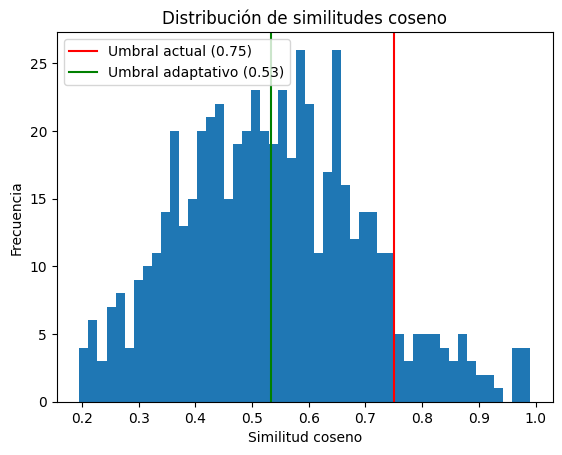

Media:    0.5377
Mediana:  0.5332
P25:      0.4180
P75:      0.5775


In [ ]:
print(f"Total similitudes calculadas: {len(todas_sims)}")

# Visualización
plt.hist(todas_sims, bins=50)
plt.axvline(x=0.75, color='red', label='Umbral actual (0.75)')
plt.axvline(x=np.percentile(todas_sims, 50), color='green',
            label=f'Umbral adaptativo ({np.percentile(todas_sims, 50):.2f})')
plt.xlabel('Similitud coseno')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('Distribución de similitudes coseno')
plt.show()

print(f"Media:    {np.mean(todas_sims):.4f}")
print(f"Mediana:  {np.median(todas_sims):.4f}")
print(f"P25:      {np.percentile(todas_sims, 25):.4f}")
print(f"P75:      {np.percentile(todas_sims, 60):.4f}")

Shape embeddings: (1212, 1024)
Total pares calculados: 733866
Media:   0.2647
Mediana: 0.2533
P75:     0.3326
P90:     0.4075
P95:     0.4550


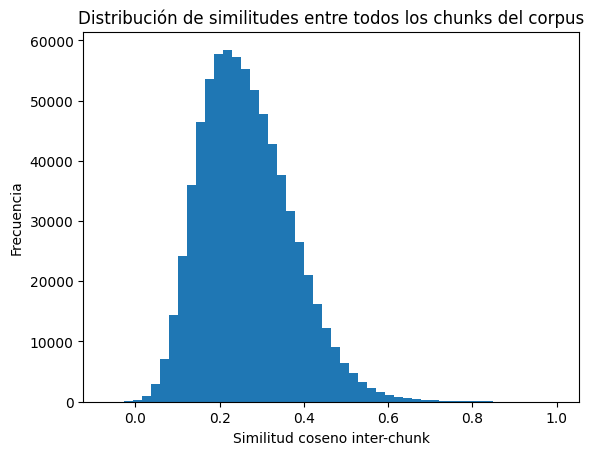

In [ ]:
#Distribución Intra-curpus de los chunks

import json
import numpy as np
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/Colab Notebooks/Cuarto curso/TFG/RAG/Chunking y embedding/chunks_output.json', 'r') as f:
    data = json.load(f)

# Extraer embeddings y normalizar
embeddings = np.array([chunk['embedding'] for chunk in data], dtype=np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_norm = embeddings / norms

print(f"Shape embeddings: {embeddings_norm.shape}")

# Matriz de similitudes completa [1212 x 1212]
sim_matrix = np.matmul(embeddings_norm, embeddings_norm.T)
np.fill_diagonal(sim_matrix, np.nan)

# Extraer valores superiores a la diagonal para no duplicar
idx_upper = np.triu_indices(len(data), k=1)
similitudes = sim_matrix[idx_upper]

print(f"Total pares calculados: {len(similitudes)}")
print(f"Media:   {np.nanmean(similitudes):.4f}")
print(f"Mediana: {np.nanmedian(similitudes):.4f}")
print(f"P75:     {np.nanpercentile(similitudes, 75):.4f}")
print(f"P90:     {np.nanpercentile(similitudes, 90):.4f}")
print(f"P95:     {np.nanpercentile(similitudes, 95):.4f}")

plt.hist(similitudes, bins=50)
plt.xlabel('Similitud coseno inter-chunk')
plt.ylabel('Frecuencia')
plt.title('Distribución de similitudes entre todos los chunks del corpus')
plt.show()

"El análisis de la distribución de similitudes inter-chunk del corpus (media = 0.26, mediana = 0.25) descarta la hipótesis de densidad semántica como causa del problema de embedding dilution. La similitud media entre chunks recuperados y fragmentos de referencia (0.54) duplica la similitud inter-chunk basal del corpus, lo que indica que el retriever discrimina correctamente los chunks relevantes. El problema de Precision@K observado con el umbral fijo de 0.75 es atribuible exclusivamente a la arbitrariedad del umbral y no a limitaciones del sistema de recuperación."

## FIGURAS ESPECÍFICAS RAG

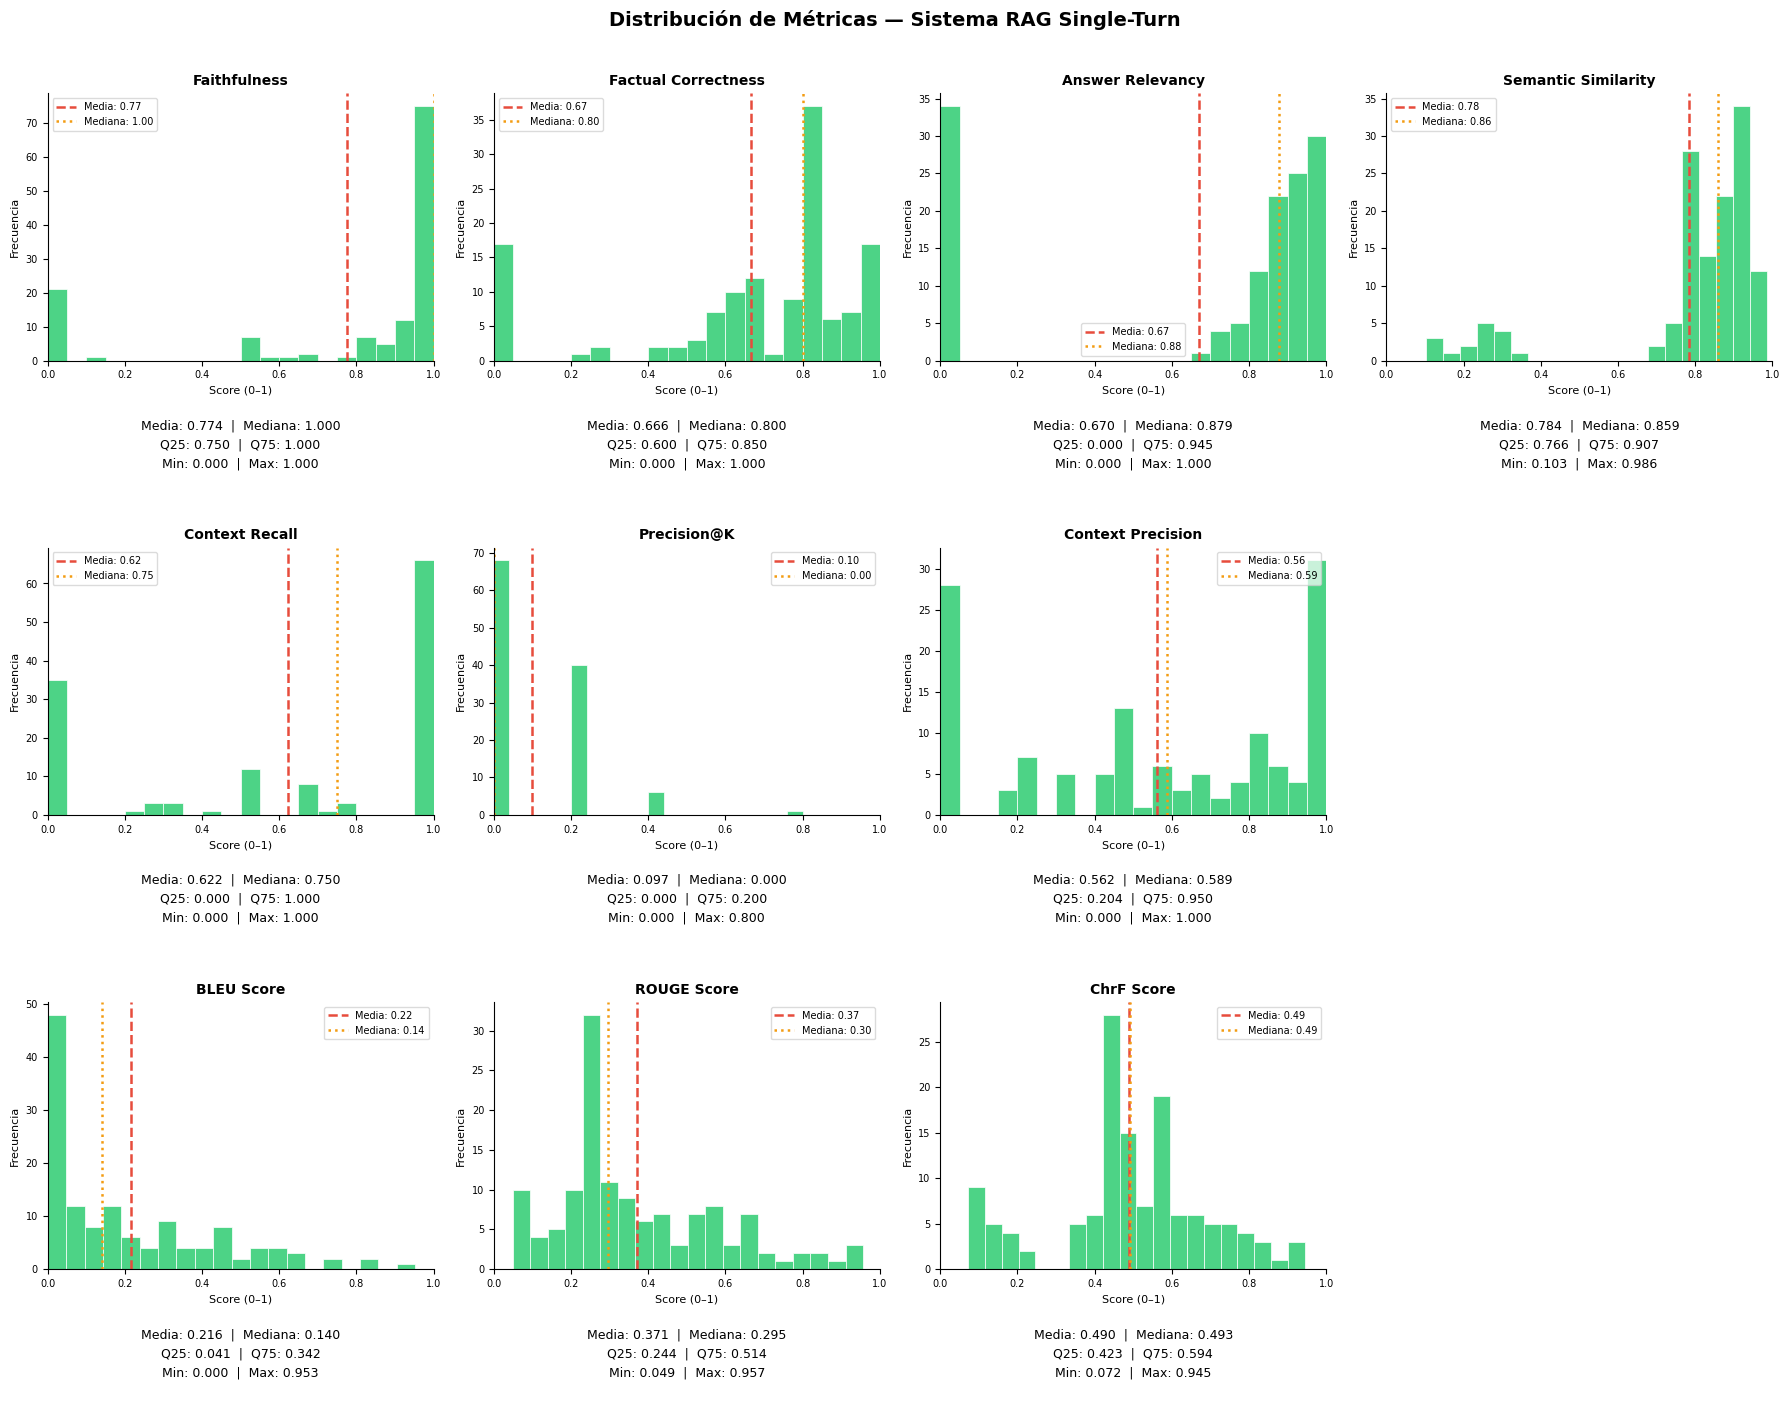

  Guardada: fig_rag_st_01_distribuciones.png


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ─────────────────────────────────────────────
#  CONFIGURACIÓN — ajustar ruta si es necesario
# ─────────────────────────────────────────────
ruta_base  = "/content/drive/MyDrive/Colab Notebooks/Cuarto curso/TFG/RAG/ResultadosEvaluacionRAG/eval_results/"
df_st_scores    = pd.read_csv(ruta_base + "scores_single_turn_rag.csv")
output_dir = Path(ruta_base)

# ── Paleta ────────────────────────────────────────────────
COLOR_BARS    = "#2ecc71"
COLOR_MEAN    = "#e74c3c"
COLOR_MEDIAN  = "#f39c12"
COLOR_RAG     = "#1abc9c"

# Gráfica 3: colores fijos por métrica
COLOR_FC      = "#1abc9c"   # teal  → Factual Correctness
COLOR_FAITH   = "#3498db"   # azul  → Faithfulness

# Gráfica 4: colores por categoría de pregunta
COLOR_TRUE    = "#2ecc71"
COLOR_TRAP    = "#e67e22"
COLOR_REASON  = "#3498db"
COLOR_OOD     = "#e74c3c"

# ── Etiquetas ─────────────────────────────────────────────
METRIC_LABELS = {
    "faithfulness"                : "Faithfulness",
    "factual_correctness(mode=f1)": "Factual Correctness",
    "answer_relevancy"            : "Answer Relevancy",
    "semantic_similarity"         : "Semantic Similarity",
    "context_recall"              : "Context Recall",
    "precision_at_k"              : "Precision@K",
    "context_precision"           : "Context Precision",
    "bleu_score"                  : "BLEU Score",
    "rouge_score(mode=fmeasure)"  : "ROUGE Score",
    "chrf_score"                  : "ChrF Score",
}

CATEGORY_LABELS = {
    "factual_true"     : "Factual True",
    "factual_trap"     : "Factual Trap",
    "factual_reasoning": "Factual Reasoning",
    "out_of_domain"    : "Out of Domain",
}

CATEGORY_ORDER = ["factual_true", "factual_reasoning",
                  "factual_trap", "out_of_domain"]

def save_fig(path: Path, fig=None):
    (fig or plt).savefig(path, dpi=150, bbox_inches="tight")
    plt.close("all")
    print(f"  Guardada: {path.name}")


# =============================================================
# GRÁFICA 1 — Distribución de todas las métricas (3 × 4 grid)
# =============================================================
def plot_distributions(df, output_dir):

    metrics = [
        "faithfulness",
        "factual_correctness(mode=f1)",
        "answer_relevancy",
        "semantic_similarity",
        # fila 2: solo 3 métricas de retrieval
        "context_recall",
        "precision_at_k",
        "context_precision",
        None,                           # ← celda vacía (posición [1][3])
        # fila 3: métricas léxicas
        "bleu_score",
        "rouge_score(mode=fmeasure)",
        "chrf_score",
    ]
    n_cols, n_rows = 4, 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14))
    fig.suptitle("Distribución de Métricas — Sistema RAG Single-Turn",
                 fontsize=14, fontweight="bold", y=1.01)

    for i, metric in enumerate(metrics):
        ax  = axes[i // n_cols][i % n_cols]
        if metric is None:
          ax.set_visible(False)
          continue

        col = df[metric].dropna()
        nans = df[metric].isna().sum()

        ax.hist(col, bins=20, color=COLOR_BARS, edgecolor="white",
                alpha=0.85, linewidth=0.6)

        mean_val   = col.mean()
        median_val = col.median()
        ax.axvline(mean_val,   color=COLOR_MEAN,   linestyle="--",
                   linewidth=1.8, label=f"Media: {mean_val:.2f}")
        ax.axvline(median_val, color=COLOR_MEDIAN, linestyle=":",
                   linewidth=1.8, label=f"Mediana: {median_val:.2f}")

        ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight="bold")
        ax.set_xlabel("Score (0–1)", fontsize=8)
        ax.set_ylabel("Frecuencia",  fontsize=8)
        ax.set_xlim(0, 1)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, framealpha=0.7)
        ax.spines[["top", "right"]].set_visible(False)

        # ── Tabla de estadísticos debajo del histograma ──
        stats_text = (
            f"Media: {mean_val:.3f}  |  Mediana: {median_val:.3f}\n"
            f"Q25: {col.quantile(0.25):.3f}  |  Q75: {col.quantile(0.75):.3f}\n"
            f"Min: {col.min():.3f}  |  Max: {col.max():.3f}\n"
            # f"NaN: {nans} ({100*nans/len(df):.1f}%)"
        )
        ax.text(
            0.5, -0.22, stats_text,      # ← -0.22 en vez de -0.30 (más pegado)
            transform   = ax.transAxes,
            fontsize    = 9,             # ← más grande
            ha          = "center",
            va          = "top",
            color       = "black",
            linespacing = 1.6,
        )

    for j in range(len(metrics), n_rows * n_cols):
        axes[j // n_cols][j % n_cols].set_visible(False)

    axes[2][3].set_visible(False)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.70)   # ← más espacio vertical para el texto
    plt.show()
    save_fig(output_dir / "fig_rag_st_01_distribuciones.png", fig)

plot_distributions(df_st_scores, output_dir)






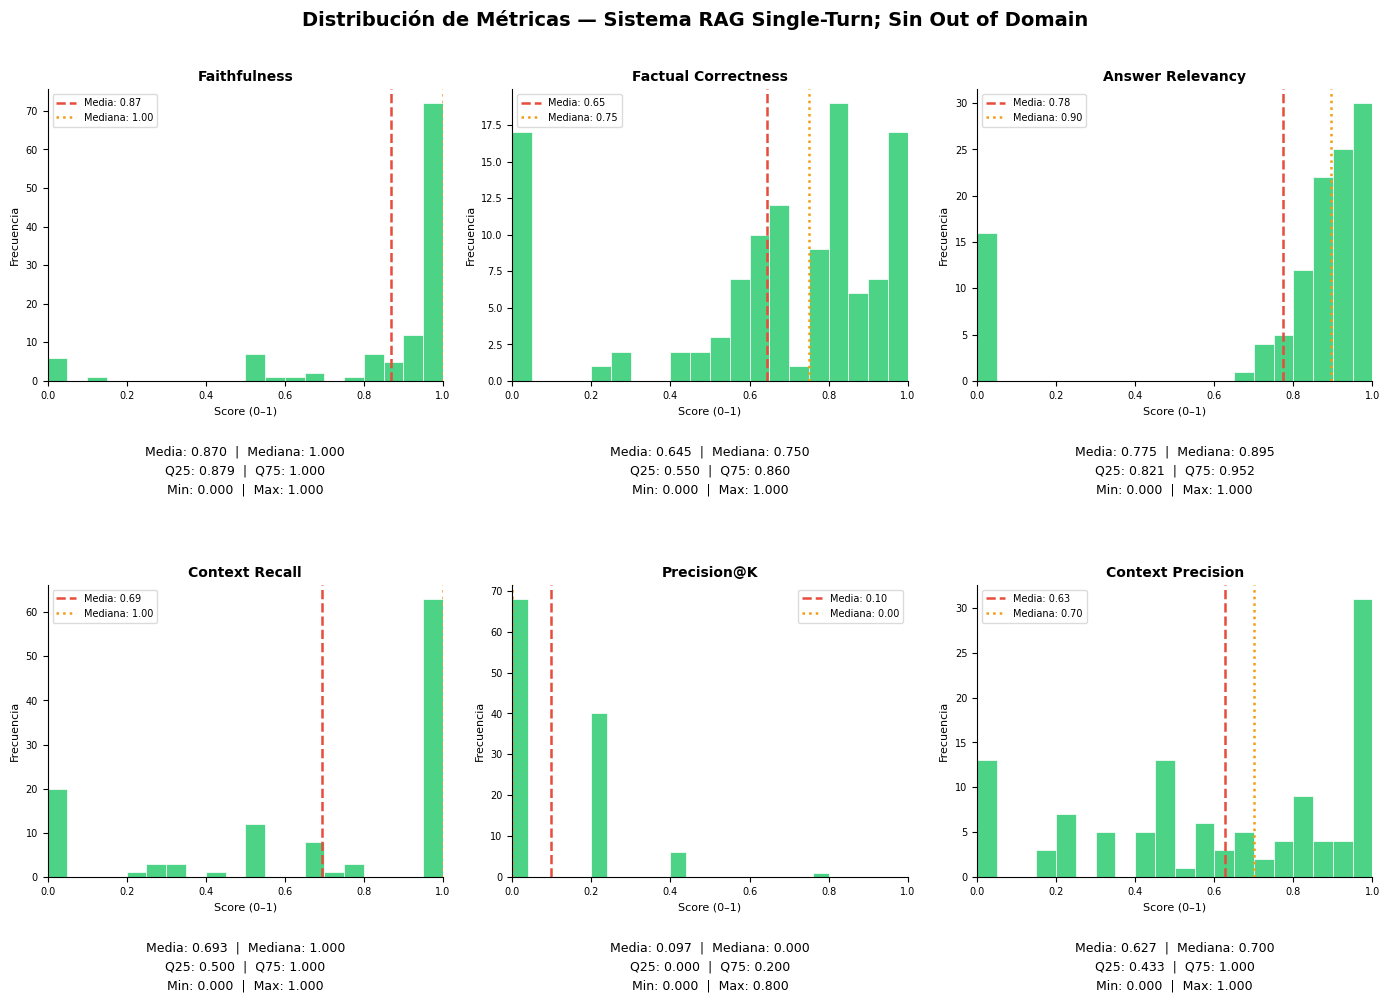

  Guardada: fig_rag_st_01b_distribuciones_sin_ood.png


In [ ]:
def plot_distributions_sin_ood(df, output_dir):

    df_filtrado = df[df["category"] != "out_of_domain"]

    metrics = [
        "faithfulness",
        "factual_correctness(mode=f1)",
        "answer_relevancy",
        "context_recall",
        "precision_at_k",
        "context_precision",
    ]

    n_cols, n_rows = 3, 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
    fig.suptitle("Distribución de Métricas — Sistema RAG Single-Turn; Sin Out of Domain",
                 fontsize=14, fontweight="bold", y=1.01)

    for i, metric in enumerate(metrics):
        ax   = axes[i // n_cols][i % n_cols]
        col  = df_filtrado[metric].dropna()
        nans = df_filtrado[metric].isna().sum()

        ax.hist(col, bins=20, color=COLOR_BARS, edgecolor="white",
                alpha=0.85, linewidth=0.6)

        mean_val   = col.mean()
        median_val = col.median()
        ax.axvline(mean_val,   color=COLOR_MEAN,   linestyle="--",
                   linewidth=1.8, label=f"Media: {mean_val:.2f}")
        ax.axvline(median_val, color=COLOR_MEDIAN, linestyle=":",
                   linewidth=1.8, label=f"Mediana: {median_val:.2f}")

        ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight="bold")
        ax.set_xlabel("Score (0–1)", fontsize=8)
        ax.set_ylabel("Frecuencia",  fontsize=8)
        ax.set_xlim(0, 1)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, framealpha=0.7)
        ax.spines[["top", "right"]].set_visible(False)

        stats_text = (
            f"Media: {mean_val:.3f}  |  Mediana: {median_val:.3f}\n"
            f"Q25: {col.quantile(0.25):.3f}  |  Q75: {col.quantile(0.75):.3f}\n"
            f"Min: {col.min():.3f}  |  Max: {col.max():.3f}"
        )
        ax.text(
            0.5, -0.22, stats_text,
            transform=ax.transAxes, fontsize=9,
            ha="center", va="top", color="black", linespacing=1.6,
        )

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.70)
    plt.show()
    save_fig(output_dir / "fig_rag_st_01b_distribuciones_sin_ood.png", fig)

plot_distributions_sin_ood(df_st_scores, output_dir)

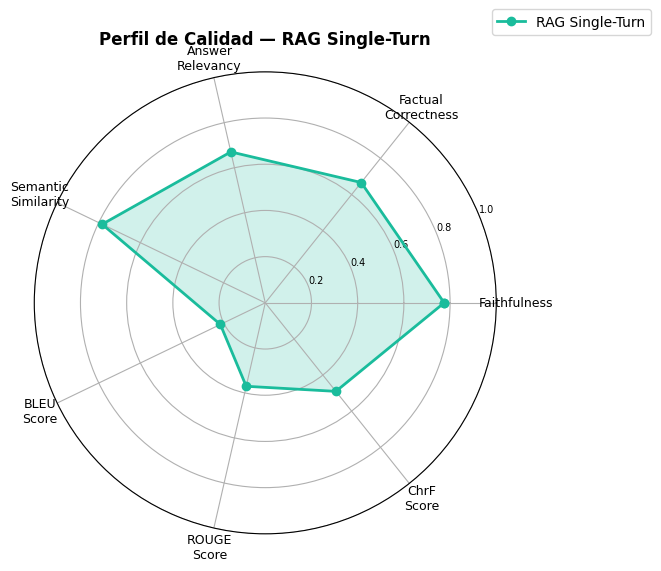

  Guardada: fig_rag_st_02_radar.png


In [ ]:
# =============================================================
# GRÁFICA 2 — Radar métricas de generación (solo RAG)
# =============================================================
def plot_radar_rag(df, output_dir):
    GENERATION_METRICS = [
        "faithfulness",
        "factual_correctness(mode=f1)",
        "answer_relevancy",
        "semantic_similarity",
        "bleu_score",
        "rouge_score(mode=fmeasure)",
        "chrf_score",
    ]
    available = [m for m in GENERATION_METRICS if m in df.columns]
    vals      = df[available].mean().tolist()
    labels    = [METRIC_LABELS[m] for m in available]

    N      = len(available)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    vals   += vals[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
    ax.plot(angles, vals, "o-", linewidth=2, color=COLOR_RAG, label="RAG Single-Turn")
    ax.fill(angles, vals, alpha=0.20, color=COLOR_RAG)
    ax.set_thetagrids(
        [a * 180 / np.pi for a in angles[:-1]],
        [l.replace(" ", "\n") for l in labels],
        fontsize=9
    )
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)
    ax.set_title("Perfil de Calidad — RAG Single-Turn",
                 pad=20, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
    plt.show()
    save_fig(output_dir / "fig_rag_st_02_radar.png", fig)

plot_radar_rag(df_st_scores, output_dir)



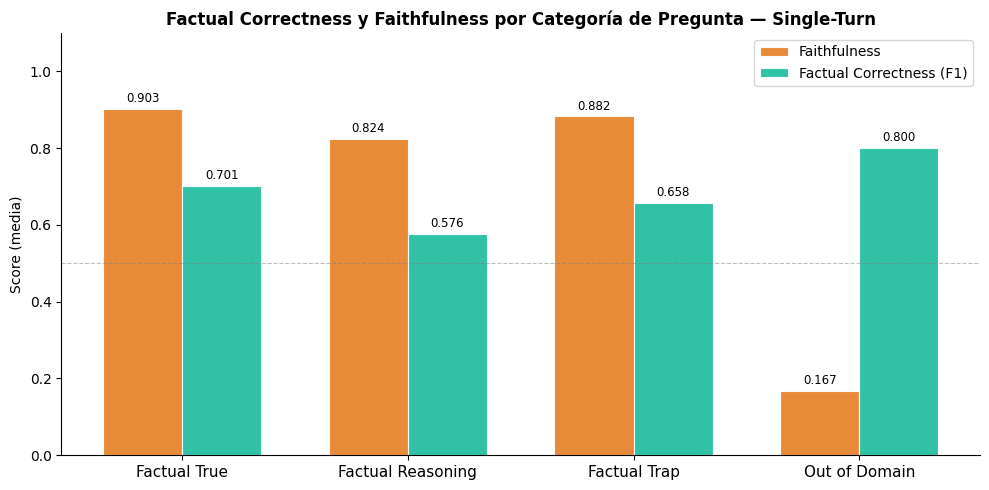

  Guardada: fig_rag_st_03_fc_faith_categoria.png


In [ ]:
# =============================================================
# GRÁFICA 3 — FC y Faithfulness por categoría  ← ACTUALIZADA
# Dos colores fijos: teal = FC, azul = Faithfulness
# =============================================================
def plot_fc_faith_by_category(df, output_dir):
    agg = (df.groupby("category")[
               ["factual_correctness(mode=f1)", "faithfulness"]
           ].mean()
           .reindex(CATEGORY_ORDER))

    x     = np.arange(len(CATEGORY_ORDER))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))

        # ── Barras Faithfulness ────────────────────────────────
    bars_fa = ax.bar(
        x - width / 2,
        agg["faithfulness"],
        width,
        color="#e67e22",
        alpha=0.90,
        edgecolor="white",
        linewidth=0.8,
        label="Faithfulness"
    )

    # ── Barras FC ──────────────────────────────────────────
    bars_fc = ax.bar(
        x + width / 2,
        agg["factual_correctness(mode=f1)"],
        width,
        color=COLOR_FC,
        alpha=0.90,
        edgecolor="white",
        linewidth=0.8,
        label="Factual Correctness (F1)"
    )



    # ── Valores encima de cada barra ──────────────────────

    for bar in bars_fa:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + 0.01, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8.5, color="black")
    for bar in bars_fc:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + 0.01, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8.5, color="black")


    # ── Línea de referencia 0.5 ───────────────────────────
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([CATEGORY_LABELS[c] for c in CATEGORY_ORDER], fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score (media)", fontsize=10)
    ax.set_title("Factual Correctness y Faithfulness por Categoría de Pregunta — Single-Turn",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.8)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_st_03_fc_faith_categoria.png", fig)

plot_fc_faith_by_category(df_st_scores, output_dir)





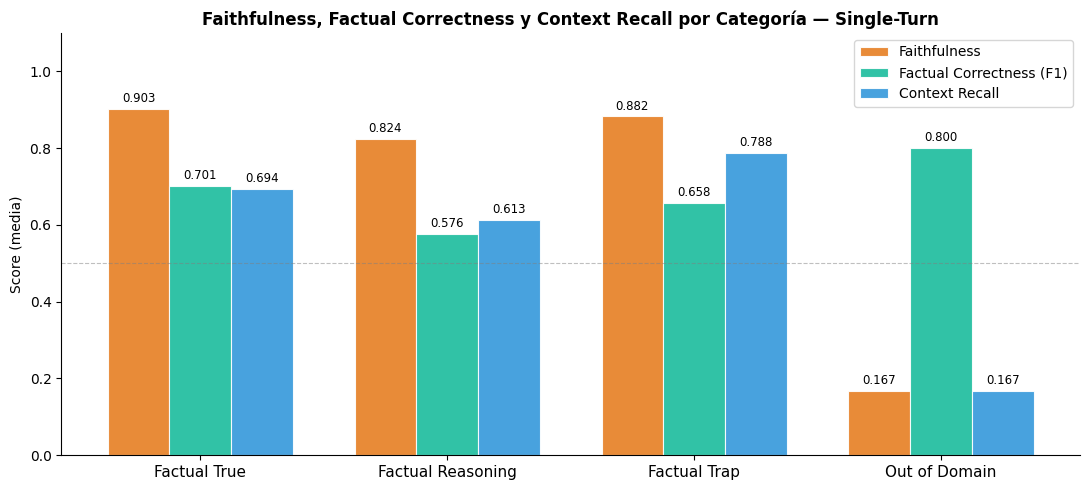

  Guardada: fig_rag_st_03b_faith_fc_cr_categoria.png


In [ ]:
# =============================================================
# GRÁFICA 3B — Faithfulness, FC y Context Recall por categoría
# =============================================================
def plot_faith_fc_cr_by_category(df, output_dir):
    agg = (df.groupby("category")[
               ["faithfulness", "factual_correctness(mode=f1)", "context_recall"]
           ].mean()
           .reindex(CATEGORY_ORDER))

    x     = np.arange(len(CATEGORY_ORDER))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))

    bars_fa = ax.bar(
        x - width, agg["faithfulness"],
        width, color="#e67e22", alpha=0.90,
        edgecolor="white", linewidth=0.8, label="Faithfulness"
    )

    bars_fc = ax.bar(
        x, agg["factual_correctness(mode=f1)"],
        width, color=COLOR_FC, alpha=0.90,
        edgecolor="white", linewidth=0.8, label="Factual Correctness (F1)"
    )

    bars_cr = ax.bar(
        x + width, agg["context_recall"],
        width, color=COLOR_REASON, alpha=0.90,
        edgecolor="white", linewidth=0.8, label="Context Recall"
    )

    for bars in [bars_fa, bars_fc, bars_cr]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + 0.01, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=8.5, color="black")

    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([CATEGORY_LABELS[c] for c in CATEGORY_ORDER], fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score (media)", fontsize=10)
    ax.set_title("Faithfulness, Factual Correctness y Context Recall por Categoría — Single-Turn",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.8)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_st_03b_faith_fc_cr_categoria.png", fig)

plot_faith_fc_cr_by_category(df_st_scores, output_dir)

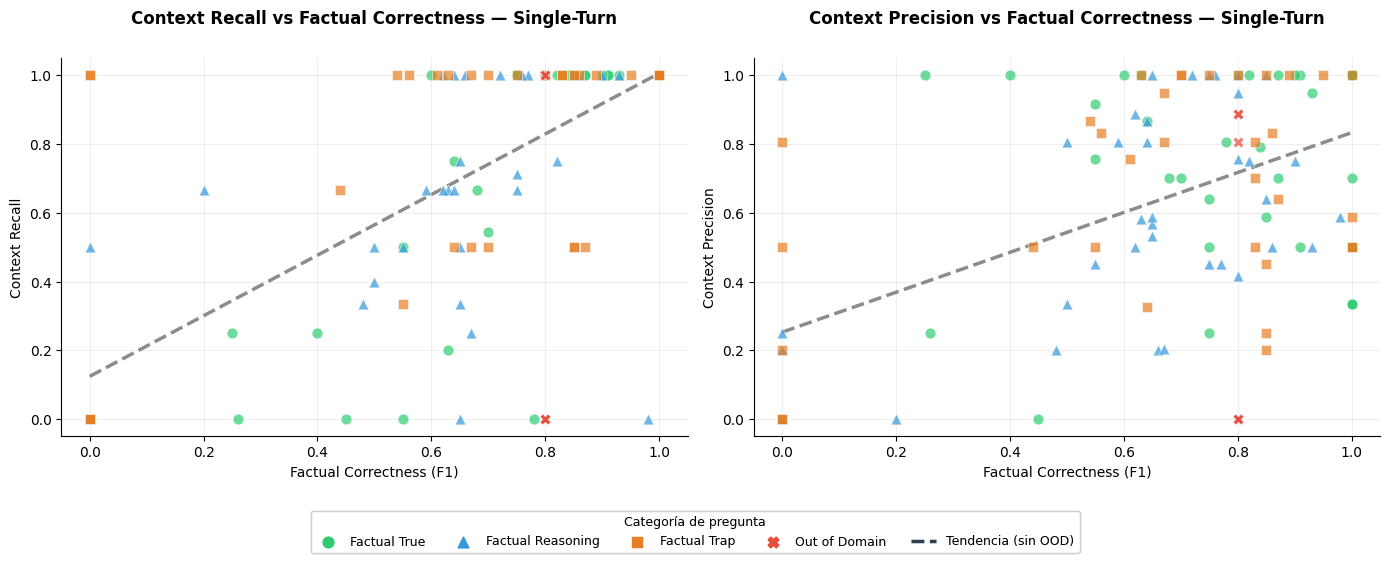

  Guardada: fig_rag_st_04_scatter_fc_retrieval.png


In [ ]:
def plot_scatter_fc_retrieval(df, output_dir):
    CATEGORY_STYLES = {
        "factual_true"     : {"color": COLOR_TRUE,   "marker": "o",
                              "label": "Factual True",      "zorder": 3},
        "factual_reasoning": {"color": COLOR_REASON, "marker": "^",
                              "label": "Factual Reasoning", "zorder": 3},
        "factual_trap"     : {"color": COLOR_TRAP,   "marker": "s",
                              "label": "Factual Trap",      "zorder": 3},
        "out_of_domain"    : {"color": COLOR_OOD,    "marker": "X",
                              "label": "Out of Domain",     "zorder": 5},
    }

    pairs = [
        ("context_recall",    "Context Recall"),
        ("context_precision", "Context Precision"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (y_metric, y_label) in zip(axes, pairs):

        for cat, style in CATEGORY_STYLES.items():
            mask = df["category"] == cat
            sub  = df[mask].dropna(
                subset=[y_metric, "factual_correctness(mode=f1)"])
            ax.scatter(
                sub["factual_correctness(mode=f1)"],
                sub[y_metric],
                c          = style["color"],
                marker     = style["marker"],
                alpha      = 0.70,
                s          = 60,
                edgecolors = "white",
                linewidths = 0.5,
                label      = style["label"],
                zorder     = style["zorder"],
            )

        df_reg = df[df["category"] != "out_of_domain"].dropna(
            subset=[y_metric, "factual_correctness(mode=f1)"])
        if len(df_reg) > 5:
            m, b = np.polyfit(df_reg["factual_correctness(mode=f1)"],
                              df_reg[y_metric], 1)
            x_line = np.linspace(0, 1, 100)
            ax.plot(x_line, m * x_line + b, "--",
                    color="gray", linewidth=2.5, alpha=0.9,
                    label="Tendencia (sin OOD)")

        ax.set_xlabel("Factual Correctness (F1)", fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{y_label} vs Factual Correctness — Single-Turn",
                     fontsize=12, fontweight="bold", pad=25)

        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(True, alpha=0.3, linewidth=0.5)

        legend_handles = [
        plt.scatter([], [], c=s["color"], marker=s["marker"],
                    s=60, label=s["label"])
        for s in CATEGORY_STYLES.values()
        ]
        legend_handles.append(
            plt.Line2D([0], [0], color="#2c3e50", linewidth=2.5,
                      linestyle="--", label="Tendencia (sin OOD)")
        )

        fig.legend(
        handles          = legend_handles,
        loc              = "upper center",
        bbox_to_anchor   = (0.5, -0.02),
        ncol             = 5,
        fontsize         = 9,
        title            = "Categoría de pregunta",
        title_fontsize   = 9,
        framealpha       = 0.88,
        )

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_st_04_scatter_fc_retrieval.png", fig)

plot_scatter_fc_retrieval(df_st_scores, output_dir)

Cálculo de la tendencia
--
Se ajusta una recta mediante regresión lineal por mínimos cuadrados (OLS). Dado un conjunto de puntos, el algoritmo encuentra la recta y = m·x + b que minimiza la suma de las distancias cuadráticas entre cada punto y la recta. El resultado es la tendencia central que mejor representa la relación entre las dos variables.

Por qué se excluyen las out_of_domain
--
En las preguntas out_of_domain el retriever recupera fragmentos que no tienen mucho o casi nada que ver con la respuesta del generador ni la de referencia, por lo que Context Recall y Context Precision serán cercanos a 0. Sin embargo, el generador interpreta correctamente que el contexto recuperado no es útil y se abstiene de responder, lo que produce una FC alta. Incluirlas distorsionaría la tendencia, ya que aparecerían como puntos con retrieval bajo pero FC alta, contradiciendo exactamente la relación que queremos mostrar.



Interpretación de la tendencia creciente
--
La pendiente positiva en ambas gráficas indica que cuando el retriever recupera contexto más relevante, el generador produce respuestas más exactas factualmente. Es decir, la calidad de la recuperación tiene un impacto directo sobre la calidad de la respuesta generada: a mayor cobertura o precisión del contexto recuperado, mayor Factual Correctness.

Por qué la pendiente es mayor en Context Recall que en Context Precision
--
Son métricas que capturan aspectos distintos del retrieval. Context Recall mide qué proporción de la respuesta de referencia está cubierta por los fragmentos recuperados, sin importar cuántos fragmentos irrelevantes haya entre ellos. Context Precision en cambio penaliza adicionalmente la posición de los fragmentos relevantes dentro del contexto recuperado: si el fragmento útil aparece en posiciones bajas tras el reranking, la métrica lo penaliza aunque ese fragmento esté presente.
Esto hace que Context Precision sea intrínsecamente más estricta y penalice más la recuperación, lo que reduce la pendiente observada. En otras palabras, dos preguntas con la misma FC pueden tener Context Recall similar pero Context Precision muy diferente dependiendo de cómo estén ordenados los fragmentos recuperados, lo que diluye la relación lineal y aplana la tendencia.

In [ ]:
"""
=============================================================
 GRÁFICAS — Evaluación Multi-Turn RAG Enfoque A (AMC)
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ─────────────────────────────────────────────
#  CONFIGURACIÓN
# ─────────────────────────────────────────────
ruta_base     = "/content/drive/MyDrive/Colab Notebooks/Cuarto curso/TFG/RAG/ResultadosEvaluacionRAG/eval_results/"
df_mt_a_scores = pd.read_csv(ruta_base + "scores_multi_turn_a_rag.csv")
output_dir    = Path(ruta_base)

# ── Paleta ────────────────────────────────────────────────
COLOR_BARS   = "#2ecc71"
COLOR_MEAN   = "#e74c3c"
COLOR_MEDIAN = "#f39c12"

# Colores por patrón conversacional
COLOR_EXPANSION  = "#1abc9c"
COLOR_FOLLOWUP   = "#3498db"
COLOR_RECOLLECT  = "#9b59b6"
COLOR_REFINEMENT = "#e74c3c"

PATTERN_COLORS = {
    "expansion" : COLOR_EXPANSION,
    "follow-up" : COLOR_FOLLOWUP,
    "recollection": COLOR_RECOLLECT,
    "refinement": COLOR_REFINEMENT,
}

PATTERN_LABELS = {
    "expansion"   : "Expansion",
    "follow-up"   : "Follow-up",
    "recollection": "Recollection",
    "refinement"  : "Refinement",
}

# Colores por tipo de turno
COLOR_CONTENT  = "#1abc9c"
COLOR_BRIDGE   = "#3498db"
COLOR_RECTEST  = "#e74c3c"

TURNTYPE_COLORS = {
    "content"         : COLOR_CONTENT,
    "bridge"          : COLOR_BRIDGE,
    "recollection-test": COLOR_RECTEST,
}

TURNTYPE_LABELS = {
    "content"          : "Content",
    "bridge"           : "Bridge",
    "recollection-test": "Recollection-Test",
}

METRIC_LABELS = {
    "faithfulness"                : "Faithfulness",
    "factual_correctness(mode=f1)": "Factual Correctness",
    "answer_relevancy"            : "Answer Relevancy",
    "semantic_similarity"         : "Semantic Similarity",
    "context_recall"              : "Context Recall",
    "bleu_score"                  : "BLEU Score",
    "rouge_score(mode=fmeasure)"  : "ROUGE Score",
    "chrf_score"                  : "ChrF Score",
}

PATTERN_ORDER  = ["expansion", "follow-up", "recollection", "refinement"]
TURNTYPE_ORDER = ["content", "bridge", "recollection-test"]

def save_fig(path: Path, fig=None):
    (fig or plt).savefig(path, dpi=150, bbox_inches="tight")
    plt.close("all")
    print(f"  Guardada: {path.name}")



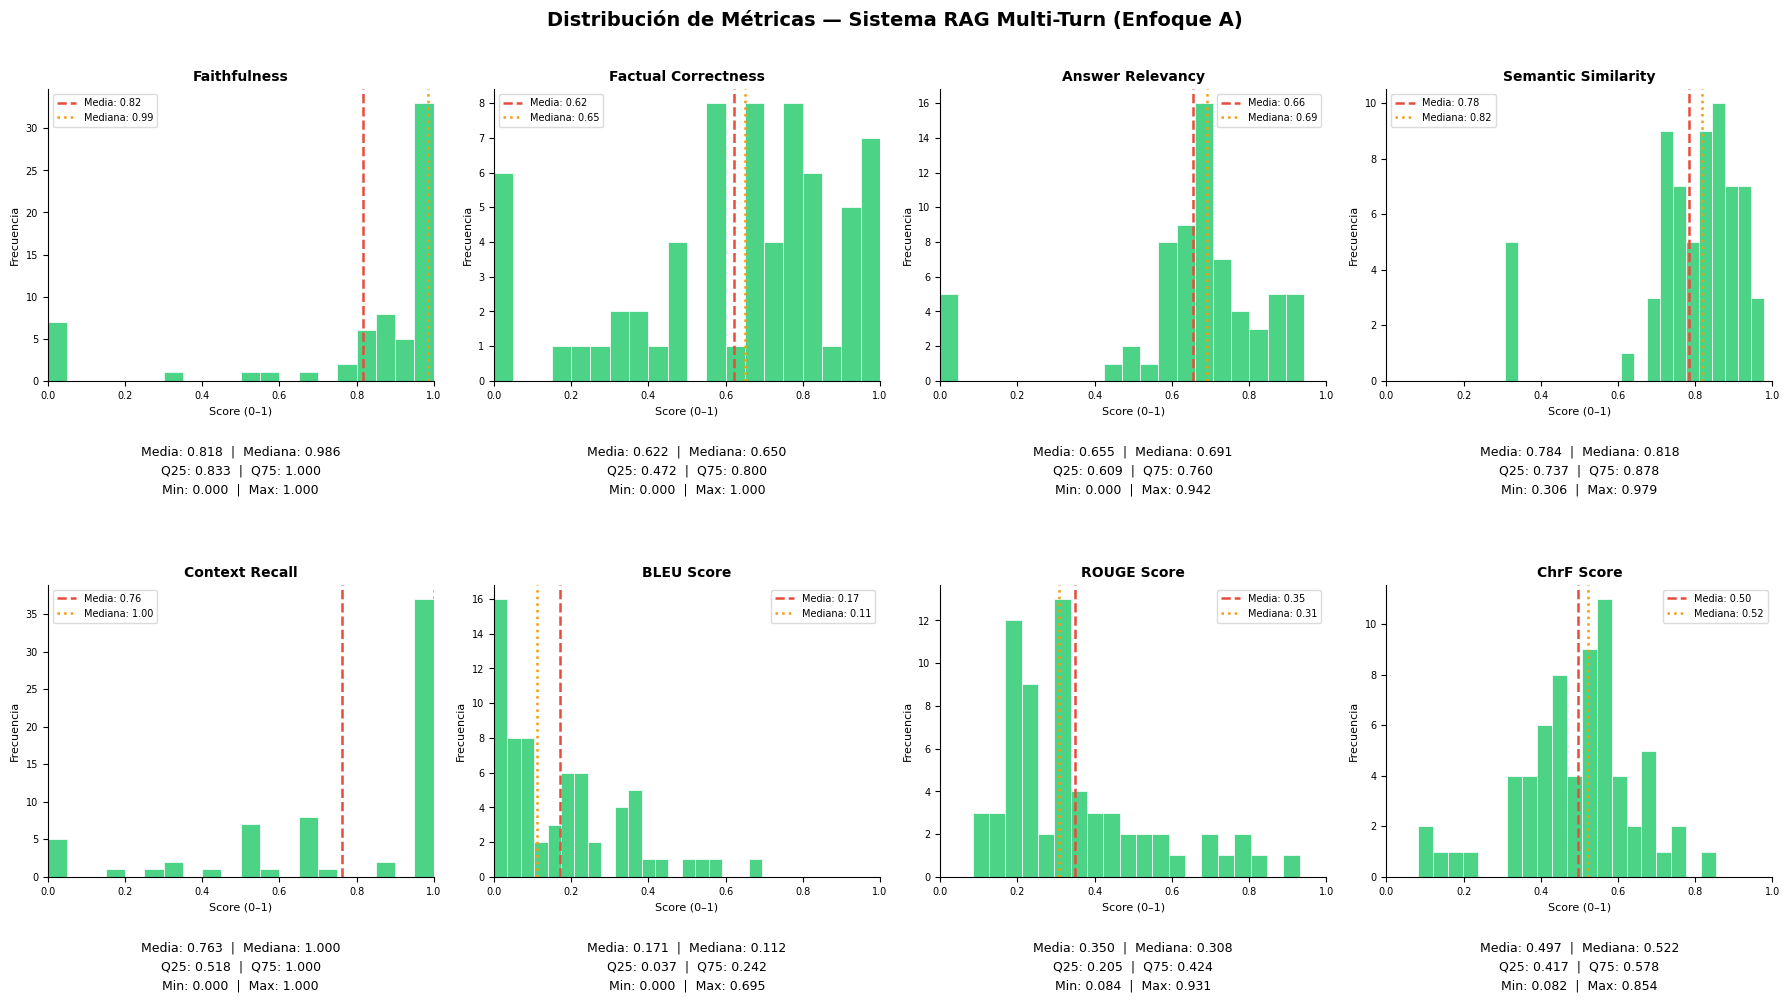

  Guardada: fig_rag_mt_01_distribuciones.png


In [ ]:

# =============================================================
# GRÁFICA 1 — Distribución métricas multi-turn (2 × 4 grid)
# =============================================================
def plot_distributions_mt(df, output_dir):
    metrics = list(METRIC_LABELS.keys())   # 8 métricas → 2 × 4
    n_cols, n_rows = 4, 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
    fig.suptitle("Distribución de Métricas — Sistema RAG Multi-Turn (Enfoque A)",
                 fontsize=14, fontweight="bold", y=1.01)

    for i, metric in enumerate(metrics):
        ax   = axes[i // n_cols][i % n_cols]
        col  = df[metric].dropna()
        nans = df[metric].isna().sum()

        ax.hist(col, bins=20, color=COLOR_BARS, edgecolor="white",
                alpha=0.85, linewidth=0.6)

        mean_val   = col.mean()
        median_val = col.median()
        ax.axvline(mean_val,   color=COLOR_MEAN,   linestyle="--",
                   linewidth=1.8, label=f"Media: {mean_val:.2f}")
        ax.axvline(median_val, color=COLOR_MEDIAN, linestyle=":",
                   linewidth=1.8, label=f"Mediana: {median_val:.2f}")

        ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight="bold")
        ax.set_xlabel("Score (0–1)", fontsize=8)
        ax.set_ylabel("Frecuencia",  fontsize=8)
        ax.set_xlim(0, 1)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, framealpha=0.7)
        ax.spines[["top", "right"]].set_visible(False)

        stats_text = (
            f"Media: {mean_val:.3f}  |  Mediana: {median_val:.3f}\n"
            f"Q25: {col.quantile(0.25):.3f}  |  Q75: {col.quantile(0.75):.3f}\n"
            f"Min: {col.min():.3f}  |  Max: {col.max():.3f}"
        )
        ax.text(0.5, -0.22, stats_text,
                transform=ax.transAxes, fontsize=9,
                ha="center", va="top", color="black", linespacing=1.6)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.70)
    plt.show()
    save_fig(output_dir / "fig_rag_mt_01_distribuciones.png", fig)

plot_distributions_mt(df_mt_a_scores, output_dir)


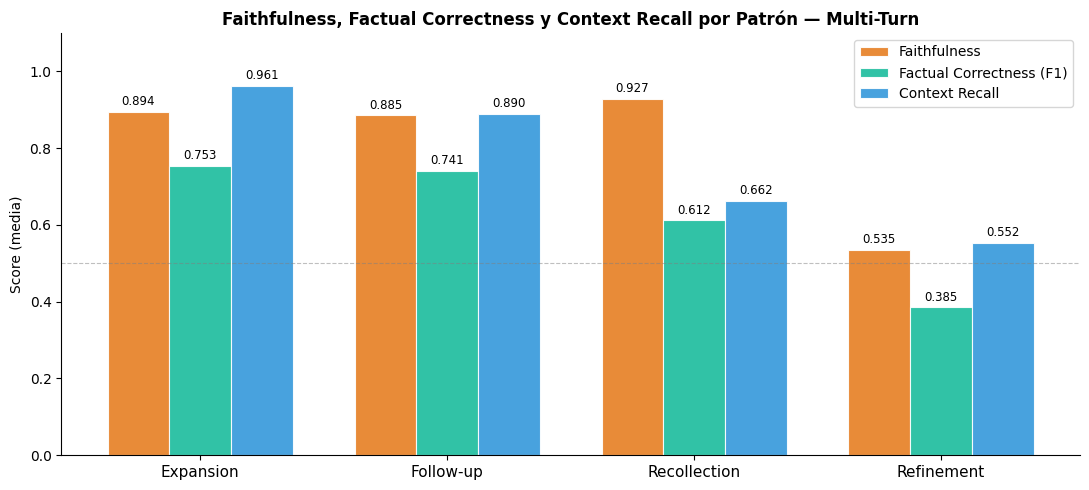

  Guardada: fig_rag_mt_02_metricas_patron.png


In [ ]:
# =============================================================
# GRÁFICA 2 — Faithfulness, FC y Context Recall por patrón
# =============================================================
def plot_metrics_by_pattern(df, output_dir):
    agg = (df.groupby("pattern")[
               ["faithfulness", "factual_correctness(mode=f1)", "context_recall"]
           ].mean()
           .reindex(PATTERN_ORDER))

    x     = np.arange(len(PATTERN_ORDER))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))

    bars_fa = ax.bar(x - width, agg["faithfulness"],
                     width, color="#e67e22", alpha=0.90,
                     edgecolor="white", linewidth=0.8, label="Faithfulness")

    bars_fc = ax.bar(x, agg["factual_correctness(mode=f1)"],
                     width, color=COLOR_EXPANSION, alpha=0.90,
                     edgecolor="white", linewidth=0.8, label="Factual Correctness (F1)")

    bars_cr = ax.bar(x + width, agg["context_recall"],
                     width, color=COLOR_FOLLOWUP, alpha=0.90,
                     edgecolor="white", linewidth=0.8, label="Context Recall")

    for bars in [bars_fa, bars_fc, bars_cr]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + 0.01, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=8.5, color="black")

    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([PATTERN_LABELS[p] for p in PATTERN_ORDER], fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score (media)", fontsize=10)
    ax.set_title("Faithfulness, Factual Correctness y Context Recall por Patrón — Multi-Turn",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.8)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_mt_02_metricas_patron.png", fig)

plot_metrics_by_pattern(df_mt_a_scores, output_dir)



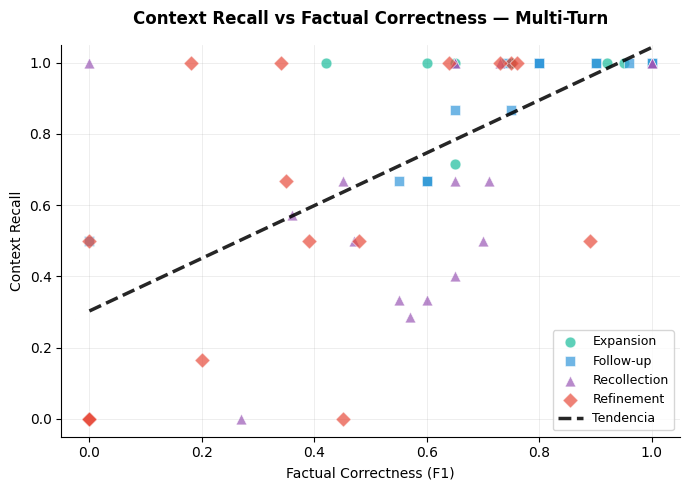

  Guardada: fig_rag_mt_03_scatter_cr_fc.png


In [ ]:
# =============================================================
# GRÁFICA 3 — Scatter Context Recall vs Factual Correctness
# =============================================================
def plot_scatter_mt(df, output_dir):
    PATTERN_STYLES = {
        "expansion"   : {"color": COLOR_EXPANSION,  "marker": "o", "zorder": 3},
        "follow-up"   : {"color": COLOR_FOLLOWUP,   "marker": "s", "zorder": 3},
        "recollection": {"color": COLOR_RECOLLECT,  "marker": "^", "zorder": 3},
        "refinement"  : {"color": COLOR_REFINEMENT, "marker": "D", "zorder": 3},
    }

    fig, ax = plt.subplots(figsize=(7, 5))

    for pat, style in PATTERN_STYLES.items():
        mask = df["pattern"] == pat
        sub  = df[mask].dropna(
            subset=["context_recall", "factual_correctness(mode=f1)"])
        ax.scatter(
            sub["factual_correctness(mode=f1)"],
            sub["context_recall"],
            c          = style["color"],
            marker     = style["marker"],
            alpha      = 0.70,
            s          = 60,
            edgecolors = "white",
            linewidths = 0.5,
            label      = PATTERN_LABELS[pat],
            zorder     = style["zorder"],
        )

    # Tendencia lineal sobre todos los patrones
    df_reg = df.dropna(subset=["context_recall", "factual_correctness(mode=f1)"])
    if len(df_reg) > 5:
        m, b = np.polyfit(df_reg["factual_correctness(mode=f1)"],
                          df_reg["context_recall"], 1)
        x_line = np.linspace(0, 1, 100)
        ax.plot(x_line, m * x_line + b,
                color="black", linewidth=2.5, linestyle="--",
                alpha=0.85, zorder=6, label="Tendencia")

    ax.set_xlabel("Factual Correctness (F1)", fontsize=10)
    ax.set_ylabel("Context Recall", fontsize=10)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title("Context Recall vs Factual Correctness — Multi-Turn",
                 fontsize=12, fontweight="bold", pad=15)
    ax.legend(fontsize=9, framealpha=0.8, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_mt_03_scatter_cr_fc.png", fig)

plot_scatter_mt(df_mt_a_scores, output_dir)



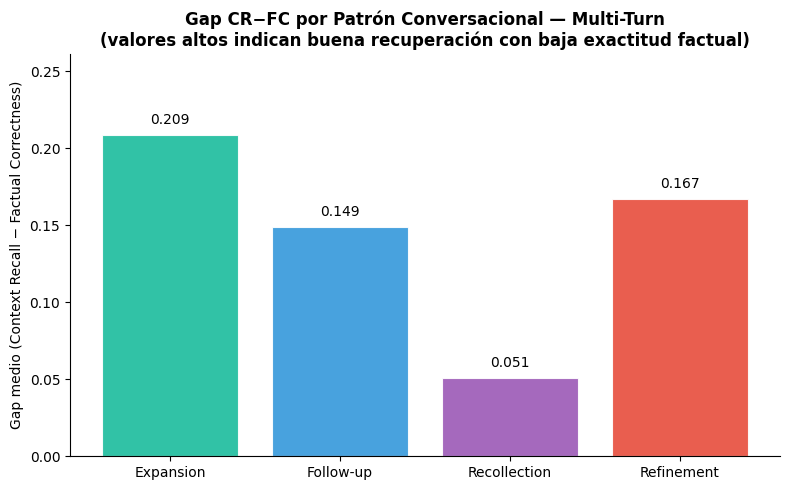

  Guardada: fig_rag_mt_04_gap_cr_fc_patron.png


In [ ]:

# =============================================================
# GRÁFICA 4 — Gap CR−FC por patrón (Afirmación 1)
# =============================================================
def plot_gap_cr_fc_by_pattern(df, output_dir):
    df = df.copy()
    df["gap_CR_FC"] = df["context_recall"] - df["factual_correctness(mode=f1)"]

    agg = (df.groupby("pattern")["gap_CR_FC"]
             .mean()
             .reindex(PATTERN_ORDER))

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        [PATTERN_LABELS[p] for p in PATTERN_ORDER],
        agg.values,
        color  = [PATTERN_COLORS[p] for p in PATTERN_ORDER],
        alpha  = 0.90,
        edgecolor = "white",
        linewidth = 0.8,
    )

    for bar, val in zip(bars, agg.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.005, f"{val:.3f}",
                ha="center", va="bottom", fontsize=10, color="black")

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="-", alpha=0.5)
    ax.set_ylabel("Gap medio (Context Recall − Factual Correctness)", fontsize=10)
    ax.set_title("Gap CR−FC por Patrón Conversacional — Multi-Turn\n"
                 "(valores altos indican buena recuperación con baja exactitud factual)",
                 fontsize=12, fontweight="bold")
    ax.set_ylim(0, max(agg.values) * 1.25)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_mt_04_gap_cr_fc_patron.png", fig)

plot_gap_cr_fc_by_pattern(df_mt_a_scores, output_dir)






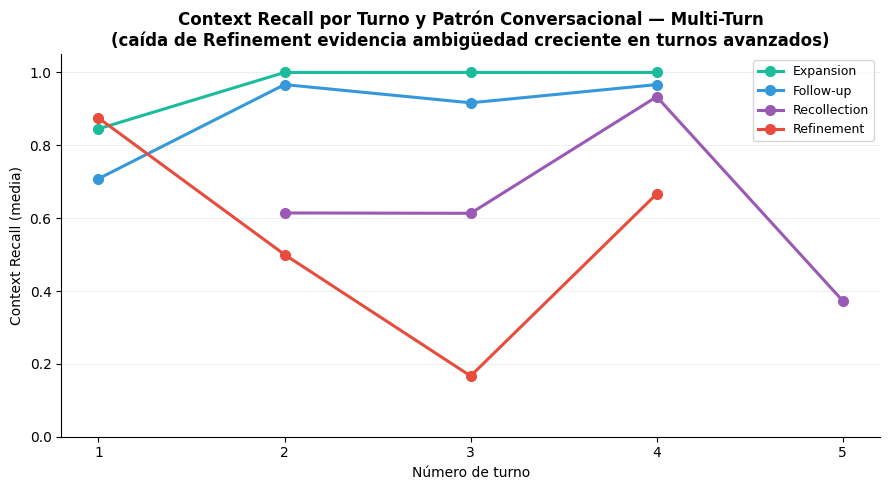

  Guardada: fig_rag_mt_05_cr_turno_patron.png


In [ ]:
# =============================================================
# GRÁFICA 5 — CR por turno dentro de cada patrón (Afirmación 3)
# =============================================================
def plot_cr_by_turn_and_pattern(df, output_dir):
    fig, ax = plt.subplots(figsize=(9, 5))

    for pat in PATTERN_ORDER:
        sub = (df[df["pattern"] == pat]
               .groupby("turn_number")["context_recall"]
               .mean()
               .reset_index())
        ax.plot(sub["turn_number"], sub["context_recall"],
                "o-",
                color     = PATTERN_COLORS[pat],
                linewidth = 2.2,
                markersize= 7,
                label     = PATTERN_LABELS[pat])

    ax.set_xlabel("Número de turno", fontsize=10)
    ax.set_ylabel("Context Recall (media)", fontsize=10)
    ax.set_title("Context Recall por Turno y Patrón Conversacional — Multi-Turn\n"
                 "(caída de Refinement evidencia ambigüedad creciente en turnos avanzados)",
                 fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(sorted(df["turn_number"].unique()))
    ax.legend(fontsize=9, framealpha=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, alpha=0.3, linewidth=0.5, axis="y")

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_mt_05_cr_turno_patron.png", fig)

plot_cr_by_turn_and_pattern(df_mt_a_scores, output_dir)

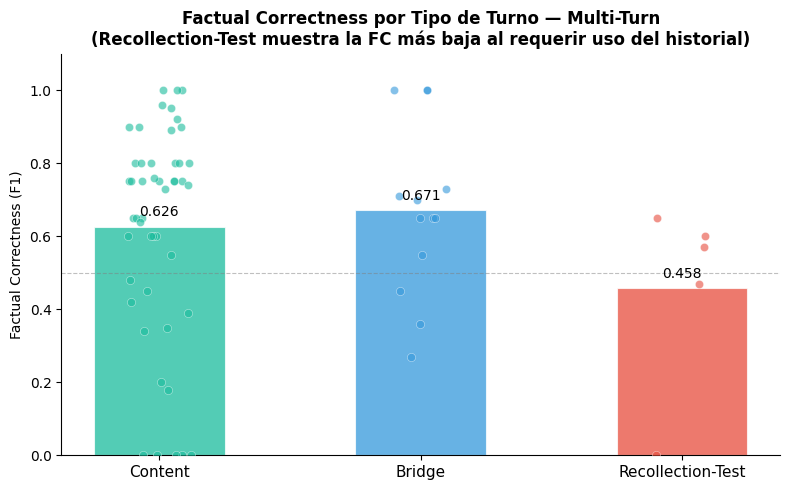

  Guardada: fig_rag_mt_06_fc_tipo_turno.png


In [ ]:
# =============================================================
# GRÁFICA 6 — FC por tipo de turno con puntos individuales (Afirmación 2)
# =============================================================
def plot_fc_by_turntype(df, output_dir):
    fig, ax = plt.subplots(figsize=(8, 5))

    for i, ttype in enumerate(TURNTYPE_ORDER):
        sub    = df[df["turn_type"] == ttype]["factual_correctness(mode=f1)"].dropna()
        media  = sub.mean()
        color  = TURNTYPE_COLORS[ttype]

        # Barra de media
        ax.bar(i, media, color=color, alpha=0.75,
               edgecolor="white", linewidth=0.8, width=0.5)

        # Puntos individuales con jitter
        jitter = np.random.uniform(-0.12, 0.12, size=len(sub))
        ax.scatter(i + jitter, sub,
                   color=color, alpha=0.6, s=35,
                   edgecolors="white", linewidths=0.4, zorder=3)

        # Valor de la media encima de la barra
        ax.text(i, media + 0.02, f"{media:.3f}",
                ha="center", va="bottom", fontsize=10, color="black")

    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(range(len(TURNTYPE_ORDER)))
    ax.set_xticklabels([TURNTYPE_LABELS[t] for t in TURNTYPE_ORDER], fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Factual Correctness (F1)", fontsize=10)
    ax.set_title("Factual Correctness por Tipo de Turno — Multi-Turn\n",
                 fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_mt_06_fc_tipo_turno.png", fig)

plot_fc_by_turntype(df_mt_a_scores, output_dir)


Recollection-Test muestra la FC más baja al requerir uso del historial

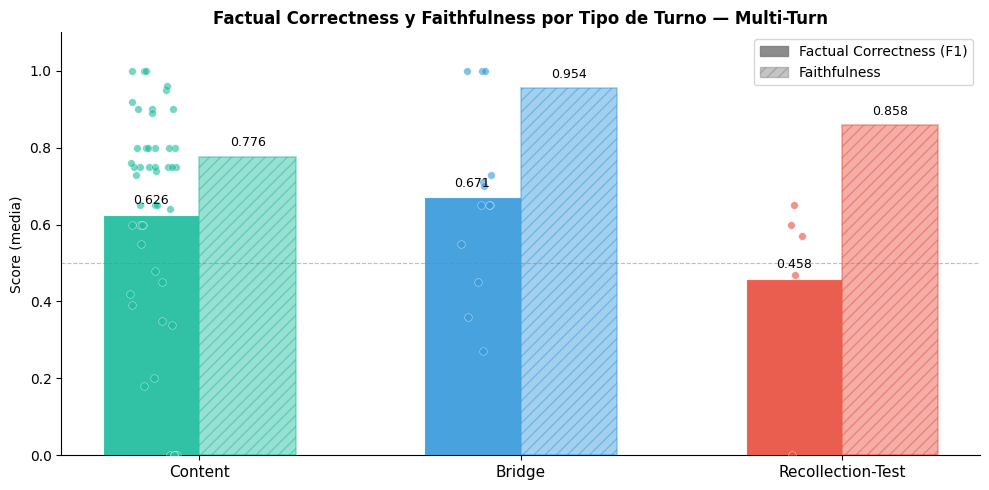

  Guardada: fig_rag_mt_06_fc_faith_tipo_turno.png


In [ ]:
def plot_fc_faith_by_turntype(df, output_dir):
    fig, ax = plt.subplots(figsize=(10, 5))

    width = 0.3

    for i, ttype in enumerate(TURNTYPE_ORDER):
        sub_fc   = df[df["turn_type"] == ttype]["factual_correctness(mode=f1)"].dropna()
        sub_fa   = df[df["turn_type"] == ttype]["faithfulness"].dropna()
        media_fc = sub_fc.mean()
        media_fa = sub_fa.mean()
        color    = TURNTYPE_COLORS[ttype]

        # Barra FC
        ax.bar(i - width/2, media_fc, width, color=color,
               alpha=0.90, edgecolor="white", linewidth=0.8,
               label="Factual Correctness" if i == 0 else "")

        # Barra Faithfulness
        ax.bar(i + width/2, media_fa, width, color=color,
               alpha=0.45, edgecolor=color, linewidth=1.2,
               hatch="///", label="Faithfulness" if i == 0 else "")

        # Puntos individuales FC con jitter
        jitter = np.random.uniform(-0.08, 0.08, size=len(sub_fc))
        ax.scatter(i - width/2 + jitter, sub_fc,
                   color=color, alpha=0.6, s=30,
                   edgecolors="white", linewidths=0.4, zorder=3)

        # Valores encima
        ax.text(i - width/2, media_fc + 0.02, f"{media_fc:.3f}",
                ha="center", va="bottom", fontsize=9, color="black")
        ax.text(i + width/2, media_fa + 0.02, f"{media_fa:.3f}",
                ha="center", va="bottom", fontsize=9, color="black")

    # Leyenda manual
    patch_fc   = mpatches.Patch(color="gray", alpha=0.90,
                                label="Factual Correctness (F1)")
    patch_fa   = mpatches.Patch(color="gray", alpha=0.45,
                                hatch="///", label="Faithfulness")
    ax.legend(handles=[patch_fc, patch_fa], fontsize=10, framealpha=0.8)

    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(range(len(TURNTYPE_ORDER)))
    ax.set_xticklabels([TURNTYPE_LABELS[t] for t in TURNTYPE_ORDER], fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score (media)", fontsize=10)
    ax.set_title("Factual Correctness y Faithfulness por Tipo de Turno — Multi-Turn",
                 fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    save_fig(output_dir / "fig_rag_mt_06_fc_faith_tipo_turno.png", fig)

plot_fc_faith_by_turntype(df_mt_a_scores, output_dir)


## FIGURAS


In [ ]:
# -*- coding: utf-8 -*-
"""
parte3c_figuras_rag.py
======================
Bloque 3 — Visualizaciones de la evaluación del sistema RAG.

ORDEN DE FIGURAS:
  Fig 01 — Barplot métricas de generación: single-turn
  Fig 02 — Barplot métricas de generación: multi-turn Enfoque A
  Fig 03 — Degradación conversacional: ST vs MT-A (FactualCorrectness)
  Fig 06 — Radar perfil de calidad global: single-turn
  Fig 07 — FactualCorrectness por categoría: single-turn
  Fig 08 — FactualCorrectness por patrón conversacional: multi-turn Enfoque A
  Fig 09 — Métricas holísticas por patrón: multi-turn Enfoque B
  Fig 11 — Boxplot FactualCorrectness: single-turn vs multi-turn Enfoque A
  Fig R01 — context_recall y precision@k por categoría: single-turn
  Fig R02 — faithfulness por categoría: single-turn
  Fig R03 — Scatter context_recall vs faithfulness: single-turn
  Fig R04 — context_recall y precision@k por patrón: multi-turn Enfoque A
  Fig R05 — Análisis de abstenciones por categoría: single-turn

Notas de adaptación desde el baseline:
  - Sin dimensión modelo × config: el RAG es un único sistema con T=0.0.
  - Fig 04 y 05 (evolución por temperatura) eliminadas: temperatura fija.
  - Fig 10 (latencia por config) sustituida por valor único en Fig 01.
  - Heatmaps sustituidos por barplots simples al no haber matriz de configuraciones.
  - Las figuras nuevas (R01–R05) conservan el mismo estilo visual que las adaptadas.
"""

# ── Imports ───────────────────────────────────────────────────────────────────
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import yaml

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURACIÓN
# =============================================================================


config = cargar_config("/content/drive/MyDrive/Colab Notebooks/Cuarto curso/TFG/RAG/Chunking y embedding/cnf.yml")

PATH_EVAL = Path(cfg["paths"]["output"]["eval_results"])
PATH_FIGS = PATH_EVAL / "figuras"
PATH_FIGS.mkdir(parents=True, exist_ok=True)

# =============================================================================
# ESTILO VISUAL
# Consistente con el baseline — mismos parámetros de tema y fuente.
# Color único para el sistema RAG: azul oscuro corporativo.
# =============================================================================

RAG_COLOR   = "#1F6FEB"   # azul principal del sistema RAG
RAG_LABEL   = "RAG (GPT-4o + Azure AI Search)"
ACCENT_COLOR = "#E8812A"  # naranja para segunda serie cuando se necesita

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family":    "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.dpi":     150,
})

# Métricas por grupo — nombres exactos que devuelve RAGAS
GENERATION_METRICS = [
    "faithfulness",
    "factual_correctness(mode=f1)",
    "answer_relevancy",
    "semantic_similarity",
    "bleu_score",
    "rouge_score(mode=fmeasure)",
    "chrf_score",
]
RETRIEVAL_METRICS = [
    "context_recall",
    "precision_at_k",
]
HOLISTIC_METRICS = [
    "hallucination_free",
    "conversational_consistency",
]

# Etiquetas legibles para las métricas
METRIC_LABELS = {
    "faithfulness":                    "Faithfulness",
    "factual_correctness(mode=f1)":    "Factual Correctness",
    "answer_relevancy":                "Answer Relevancy",
    "semantic_similarity":             "Semantic Similarity",
    "bleu_score":                      "BLEU Score",
    "rouge_score(mode=fmeasure)":      "ROUGE Score",
    "chrf_score":                      "ChrF Score",
    "context_recall":                  "Context Recall",
    "precision_at_k":                  "Precision@K",
    "hallucination_free":              "Hallucination Free",
    "conversational_consistency":      "Conv. Consistency",
}

CATEGORY_LABELS = {
    "factual_true":      "Factual\nTrue",
    "factual_reasoning": "Factual\nReasoning",
    "factual_trap":      "Factual\nTrap",
    "out_of_domain":     "Out of\nDomain",
}

PATTERN_LABELS = {
    "expansion":    "Expansion\n(consistencia interna)",
    "refinement":   "Refinement\n(autocorrección)",
    "follow-up":    "Follow-up\n(coherencia local)",
    "recollection": "Recollection\n(memoria lejana)",
}


def get_available(df: pd.DataFrame, candidates: list) -> list:
    return [m for m in candidates if m in df.columns]


# =============================================================================
# CARGA DE DATOS
# =============================================================================

def load_csv(name: str) -> pd.DataFrame:
    path = PATH_EVAL / name
    if not path.exists():
        print(f"  No encontrado: {name}")
        return pd.DataFrame()
    return pd.read_csv(path)


df_st_scores   = load_csv("scores_single_turn_rag.csv")
df_mt_a_scores = load_csv("scores_multi_turn_a_rag.csv")
df_mt_b_scores = load_csv("scores_multi_turn_b_rag.csv")

# Raw responses para la figura de abstenciones
raw_files = sorted(Path(cfg["paths"]["output"]["raw_responses"]).glob(
    "raw_responses_rag_*.json"
))
df_raw = pd.DataFrame()
if raw_files:
    with open(raw_files[-1], encoding="utf-8") as f:
        df_raw = pd.DataFrame(json.load(f))

print(f"Datos cargados:")
print(f"  Single-turn     : {len(df_st_scores)} registros")
print(f"  Multi-turn A    : {len(df_mt_a_scores)} registros")
print(f"  Multi-turn B    : {len(df_mt_b_scores)} registros")
print(f"  Raw responses   : {len(df_raw)} registros")



def save_fig(filename: str) -> None:
    path = PATH_FIGS / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"    Guardada: {filename}")


In [ ]:



def plot_fig01_barplot_single_turn(scores_df: pd.DataFrame) -> None:
    available = get_available(scores_df, GENERATION_METRICS)
    if not available:
        return

    means = [scores_df[m].dropna().mean() for m in available]
    stds  = [scores_df[m].dropna().std()  for m in available]
    labels = [METRIC_LABELS.get(m, m) for m in available]

    fig, ax = plt.subplots(figsize=(9, 5))
    y = np.arange(len(available))
    bars = ax.barh(y, means, xerr=stds, capsize=4,
                   color=RAG_COLOR, alpha=0.85, edgecolor="white", height=0.6)

    # Anotación del valor medio
    for bar, mean in zip(bars, means):
        ax.text(mean + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{mean:.3f}", va="center", fontsize=9, color="#333")

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Score (0–1)")
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.4, linewidth=1,
               label="Umbral referencia (0.5)")
    ax.set_title(f"Métricas de Generación — Single-Turn\n{RAG_LABEL}",
                 fontsize=12)
    ax.legend(fontsize=8)
    save_fig("fig01_barplot_single_turn.png")


plot_fig01_barplot_single_turn(df_st_scores)



In [ ]:


def plot_fig02_barplot_multi_turn_a(scores_df: pd.DataFrame) -> None:
    exclude  = {"answer_relevancy"}
    available = [m for m in get_available(scores_df, GENERATION_METRICS)
                 if m not in exclude]
    if not available:
        return

    means  = [scores_df[m].dropna().mean() for m in available]
    stds   = [scores_df[m].dropna().std()  for m in available]
    labels = [METRIC_LABELS.get(m, m) for m in available]

    fig, ax = plt.subplots(figsize=(9, 5))
    y    = np.arange(len(available))
    bars = ax.barh(y, means, xerr=stds, capsize=4,
                   color=RAG_COLOR, alpha=0.85, edgecolor="white", height=0.6)

    for bar, mean in zip(bars, means):
        ax.text(mean + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{mean:.3f}", va="center", fontsize=9, color="#333")

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Score (0–1)")
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.4, linewidth=1,
               label="Umbral referencia (0.5)")
    ax.set_title("Métricas de Generación — Multi-Turn Enfoque A\n"
                 f"{RAG_LABEL}\n(Answer Relevancy excluida — historial en user_input)",
                 fontsize=11)
    ax.legend(fontsize=8)
    save_fig("fig02_barplot_multi_turn_a.png")


plot_fig02_barplot_multi_turn_a(df_mt_a_scores)

In [ ]:

def plot_fig03_degradacion(df_st: pd.DataFrame, df_mt: pd.DataFrame) -> None:
    metric = "factual_correctness(mode=f1)"
    if metric not in df_st.columns or metric not in df_mt.columns:
        return

    st_mean = df_st[metric].dropna().mean()
    mt_mean = df_mt[metric].dropna().mean()
    delta   = mt_mean - st_mean

    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.array([0, 1])
    bars = ax.bar(x, [st_mean, mt_mean], width=0.4,
                  color=[RAG_COLOR, RAG_COLOR],
                  alpha=[0.9, 0.55],
                  hatch=["", "//"],
                  edgecolor="white")

    # Anotación del delta
    color = "red" if delta < 0 else "green"
    ax.annotate(f"Δ {delta:+.3f}", xy=(1, mt_mean),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=10, color=color, weight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(["Single-Turn", "Multi-Turn\n(historial real)"], fontsize=10)
    ax.set_ylabel("Factual Correctness (media global)")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, linewidth=1)
    ax.set_title(f"Degradación Conversacional — Factual Correctness\n{RAG_LABEL}")

    solid_patch   = mpatches.Patch(color=RAG_COLOR, alpha=0.9, label="Single-Turn")
    hatched_patch = mpatches.Patch(facecolor=RAG_COLOR, alpha=0.55,
                                    hatch="//", label="Multi-Turn (historial real)")
    ax.legend(handles=[solid_patch, hatched_patch], fontsize=9)
    save_fig("fig03_degradacion_factual_correctness.png")


plot_fig03_degradacion(df_st_scores, df_mt_a_scores)


In [ ]:

def plot_fig06_radar(scores_df: pd.DataFrame) -> None:
    available = get_available(scores_df, GENERATION_METRICS)
    if len(available) < 3:
        return

    means  = scores_df[available].mean().tolist()
    labels = [METRIC_LABELS.get(m, m).replace(" ", "\n") for m in available]
    N      = len(available)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    vals    = means + means[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
    ax.plot(angles, vals, "o-", linewidth=2, color=RAG_COLOR)
    ax.fill(angles, vals, alpha=0.15, color=RAG_COLOR)
    ax.set_thetagrids([a * 180 / np.pi for a in angles[:-1]], labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f"Perfil de Calidad Global — Single-Turn\n{RAG_LABEL}",
                 pad=20, fontsize=12)
    save_fig("fig06_radar_single_turn.png")


plot_fig06_radar(df_st_scores)


In [ ]:

def plot_fig07_por_categoria(scores_df: pd.DataFrame) -> None:
    metric = "factual_correctness(mode=f1)"
    if metric not in scores_df.columns or "category" not in scores_df.columns:
        return

    cats   = [c for c in CATEGORY_LABELS if c in scores_df["category"].unique()]
    means  = [scores_df[scores_df["category"] == c][metric].dropna().mean() for c in cats]
    stds   = [scores_df[scores_df["category"] == c][metric].dropna().std()  for c in cats]
    counts = [scores_df["category"].value_counts().get(c, 0) for c in cats]
    labels = [CATEGORY_LABELS.get(c, c) for c in cats]

    fig, ax = plt.subplots(figsize=(9, 4))
    x    = np.arange(len(cats))
    bars = ax.bar(x, means, yerr=stds, capsize=5,
                  color=RAG_COLOR, alpha=0.85, edgecolor="white", width=0.5)

    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.03,
                f"n={count}", ha="center", fontsize=8, color="gray")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Factual Correctness (media ± std)")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.5,
               label="Umbral alucinación (FC < 0.5)")
    ax.set_title(f"Factual Correctness por Categoría — Single-Turn\n{RAG_LABEL}")
    ax.legend(fontsize=8)
    save_fig("fig07_por_categoria.png")


plot_fig07_por_categoria(df_st_scores)



In [ ]:

def plot_fig08_por_patron(scores_df: pd.DataFrame) -> None:
    metric = "factual_correctness(mode=f1)"
    if metric not in scores_df.columns or "pattern" not in scores_df.columns:
        return

    patterns = [p for p in PATTERN_LABELS if p in scores_df["pattern"].unique()]
    means    = [scores_df[scores_df["pattern"] == p][metric].dropna().mean()
                for p in patterns]
    stds     = [scores_df[scores_df["pattern"] == p][metric].dropna().std()
                for p in patterns]
    labels   = [PATTERN_LABELS.get(p, p) for p in patterns]

    fig, ax = plt.subplots(figsize=(10, 4))
    x    = np.arange(len(patterns))
    bars = ax.bar(x, means, yerr=stds, capsize=5,
                  color=RAG_COLOR, alpha=0.85, edgecolor="white", width=0.5)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.03,
                f"{mean:.3f}", ha="center", fontsize=9, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Factual Correctness (media ± std)")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.5,
               label="Umbral alucinación (FC < 0.5)")
    ax.set_title("Factual Correctness por Patrón Conversacional\n"
                 f"Multi-Turn Enfoque A — {RAG_LABEL}")
    ax.legend(fontsize=8)
    save_fig("fig08_por_patron.png")


plot_fig08_por_patron(df_mt_a_scores)

In [ ]:

def plot_fig09_holistica_por_patron(scores_df: pd.DataFrame) -> None:
    if scores_df.empty:
        return
    available = get_available(scores_df, HOLISTIC_METRICS)
    if not available or "pattern" not in scores_df.columns:
        return

    patterns = [p for p in PATTERN_LABELS if p in scores_df["pattern"].unique()]
    n        = len(available)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, metric in zip(axes, available):
        means  = [scores_df[scores_df["pattern"] == p][metric].dropna().mean()
                  for p in patterns]
        labels = [PATTERN_LABELS.get(p, p).split("\n")[0] for p in patterns]

        x    = np.arange(len(patterns))
        bars = ax.bar(x, means, color=RAG_COLOR, alpha=0.85,
                      edgecolor="white", width=0.5)

        for bar, mean in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.05,
                    f"{mean:.2f}", ha="center", fontsize=9, color="#333")

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ylim = 1.2 if "hallucination" in metric else 5.5
        ax.set_ylim(0, ylim)
        ax.set_title(METRIC_LABELS.get(metric, metric))
        ax.set_ylabel("Score")

    fig.suptitle(f"Evaluación Holística por Patrón — Multi-Turn Enfoque B\n{RAG_LABEL}",
                 fontsize=12)
    save_fig("fig09_holistica_por_patron.png")


plot_fig09_holistica_por_patron(df_mt_b_scores)



In [ ]:

def plot_fig11_boxplot_st_vs_mt(df_st: pd.DataFrame, df_mt: pd.DataFrame) -> None:
    metric = "factual_correctness(mode=f1)"
    if metric not in df_st.columns or metric not in df_mt.columns:
        return

    data_st = df_st[metric].dropna().values
    data_mt = df_mt[metric].dropna().values

    fig, ax = plt.subplots(figsize=(7, 4))
    bp = ax.boxplot(
        [data_st, data_mt],
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2},
        widths=0.4,
    )
    colors = [RAG_COLOR, RAG_COLOR]
    alphas = [0.9, 0.55]
    for patch, color, alpha in zip(bp["boxes"], colors, alphas):
        patch.set_facecolor(color)
        patch.set_alpha(alpha)

    ax.set_xticklabels(["Single-Turn", "Multi-Turn\n(Enfoque A)"], fontsize=10)
    ax.set_ylabel("Factual Correctness (0–1)")
    ax.set_title(f"Distribución de Factual Correctness\nSingle-Turn vs Multi-Turn — {RAG_LABEL}")
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, linewidth=1)

    solid_patch   = mpatches.Patch(color=RAG_COLOR, alpha=0.9, label="Single-Turn")
    hatched_patch = mpatches.Patch(facecolor=RAG_COLOR, alpha=0.55, label="Multi-Turn")
    ax.legend(handles=[solid_patch, hatched_patch], fontsize=9)
    save_fig("fig11_boxplot_st_vs_mt_factual_correctness.png")


plot_fig11_boxplot_st_vs_mt(df_st_scores, df_mt_a_scores)


In [ ]:

def plot_figR01_retrieval_por_categoria(scores_df: pd.DataFrame) -> None:
    metrics = [m for m in RETRIEVAL_METRICS if m in scores_df.columns]
    if not metrics or "category" not in scores_df.columns:
        return

    cats   = [c for c in CATEGORY_LABELS if c in scores_df["category"].unique()]
    labels = [CATEGORY_LABELS.get(c, c) for c in cats]
    x      = np.arange(len(cats))
    width  = 0.35
    colors = [RAG_COLOR, ACCENT_COLOR]

    fig, ax = plt.subplots(figsize=(10, 4))

    for i, metric in enumerate(metrics):
        means = [scores_df[scores_df["category"] == c][metric].dropna().mean()
                 for c in cats]
        offset = (i - len(metrics) / 2 + 0.5) * width
        bars = ax.bar(x + offset, means, width,
                      color=colors[i], alpha=0.85, edgecolor="white",
                      label=METRIC_LABELS.get(metric, metric))
        for bar, mean in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{mean:.2f}", ha="center", fontsize=8, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Score (0–1)")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)
    ax.set_title(f"Métricas de Retrieval por Categoría — Single-Turn\n{RAG_LABEL}")
    ax.legend(fontsize=9)
    save_fig("figR01_retrieval_por_categoria.png")


plot_figR01_retrieval_por_categoria(df_st_scores)

In [ ]:

def plot_figR02_faithfulness_por_categoria(scores_df: pd.DataFrame) -> None:
    metrics = ["faithfulness", "factual_correctness(mode=f1)"]
    metrics = [m for m in metrics if m in scores_df.columns]
    if not metrics or "category" not in scores_df.columns:
        return

    cats   = [c for c in CATEGORY_LABELS if c in scores_df["category"].unique()]
    labels = [CATEGORY_LABELS.get(c, c) for c in cats]
    x      = np.arange(len(cats))
    width  = 0.35
    colors = [RAG_COLOR, ACCENT_COLOR]

    fig, ax = plt.subplots(figsize=(10, 4))

    for i, metric in enumerate(metrics):
        means = [scores_df[scores_df["category"] == c][metric].dropna().mean()
                 for c in cats]
        offset = (i - len(metrics) / 2 + 0.5) * width
        bars = ax.bar(x + offset, means, width,
                      color=colors[i], alpha=0.85, edgecolor="white",
                      label=METRIC_LABELS.get(metric, metric))
        for bar, mean in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{mean:.2f}", ha="center", fontsize=8, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Score (0–1)")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, linewidth=1,
               label="Umbral referencia (0.5)")
    ax.set_title(f"Faithfulness y Factual Correctness por Categoría — Single-Turn\n"
                 f"{RAG_LABEL}")
    ax.legend(fontsize=9)
    save_fig("figR02_faithfulness_por_categoria.png")


plot_figR02_faithfulness_por_categoria(df_st_scores)

In [ ]:

def plot_figR03_scatter_recall_faithfulness(scores_df: pd.DataFrame) -> None:
    x_col = "context_recall"
    y_col = "faithfulness"
    if x_col not in scores_df.columns or y_col not in scores_df.columns:
        return

    df_plot = scores_df[[x_col, y_col, "category"]].dropna()
    if df_plot.empty:
        return

    # Color por categoría usando paleta consistente con el resto de figuras
    cat_colors = {
        "factual_true":      "#1F6FEB",
        "factual_reasoning": "#E8812A",
        "factual_trap":      "#2CA02C",
        "out_of_domain":     "#9467BD",
    }

    fig, ax = plt.subplots(figsize=(7, 6))

    for cat, group in df_plot.groupby("category"):
        ax.scatter(
            group[x_col], group[y_col],
            color=cat_colors.get(cat, "#888"),
            alpha=0.65, s=55, edgecolors="white", linewidths=0.5,
            label=CATEGORY_LABELS.get(cat, cat).replace("\n", " "),
        )

    # Línea de tendencia global
    z    = np.polyfit(df_plot[x_col], df_plot[y_col], 1)
    p    = np.poly1d(z)
    xline = np.linspace(df_plot[x_col].min(), df_plot[x_col].max(), 100)
    ax.plot(xline, p(xline), "--", color="gray", linewidth=1.5,
            alpha=0.7, label=f"Tendencia (pendiente={z[0]:.2f})")

    ax.set_xlabel(METRIC_LABELS.get(x_col, x_col))
    ax.set_ylabel(METRIC_LABELS.get(y_col, y_col))
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="red", linestyle=":", alpha=0.3, linewidth=1)
    ax.axvline(0.5, color="red", linestyle=":", alpha=0.3, linewidth=1)
    ax.set_title(f"Context Recall vs Faithfulness — Single-Turn\n{RAG_LABEL}")
    ax.legend(fontsize=8, loc="lower right")
    save_fig("figR03_scatter_recall_faithfulness.png")


plot_figR03_scatter_recall_faithfulness(df_st_scores)


In [ ]:

def plot_figR04_retrieval_por_patron(scores_df: pd.DataFrame) -> None:
    metrics = [m for m in RETRIEVAL_METRICS if m in scores_df.columns]
    if not metrics or "pattern" not in scores_df.columns:
        return

    patterns = [p for p in PATTERN_LABELS if p in scores_df["pattern"].unique()]
    labels   = [PATTERN_LABELS.get(p, p) for p in patterns]
    x        = np.arange(len(patterns))
    width    = 0.35
    colors   = [RAG_COLOR, ACCENT_COLOR]

    fig, ax = plt.subplots(figsize=(10, 4))

    for i, metric in enumerate(metrics):
        means = [scores_df[scores_df["pattern"] == p][metric].dropna().mean()
                 for p in patterns]
        offset = (i - len(metrics) / 2 + 0.5) * width
        bars = ax.bar(x + offset, means, width,
                      color=colors[i], alpha=0.85, edgecolor="white",
                      label=METRIC_LABELS.get(metric, metric))
        for bar, mean in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f"{mean:.2f}", ha="center", fontsize=8, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Score (0–1)")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)
    ax.set_title(f"Métricas de Retrieval por Patrón Conversacional\n"
                 f"Multi-Turn Enfoque A — {RAG_LABEL}")
    ax.legend(fontsize=9)
    save_fig("figR04_retrieval_por_patron.png")


plot_figR04_retrieval_por_patron(df_mt_a_scores)

In [ ]:

def plot_figR05_abstenciones(df_raw: pd.DataFrame) -> None:
    if df_raw.empty or "response" not in df_raw.columns:
        return

    df_st_raw = df_raw[df_raw["type"] == "single_turn"].copy()
    if df_st_raw.empty:
        return

    # Detectar abstenciones por las dos frases posibles
    # (inglés antes de la corrección, castellano después)
    abstension_mask = (
        df_st_raw["response"].str.contains(
            "No dispongo de|do not have enough information",
            case=False, na=False
        )
    )
    df_st_raw["abstension"] = abstension_mask

    cats   = [c for c in CATEGORY_LABELS if c in df_st_raw["category"].unique()]
    labels = [CATEGORY_LABELS.get(c, c) for c in cats]

    total_por_cat     = [len(df_st_raw[df_st_raw["category"] == c]) for c in cats]
    abstenciones_cat  = [df_st_raw[df_st_raw["category"] == c]["abstension"].sum()
                         for c in cats]
    pct_abstenciones  = [a / t * 100 if t > 0 else 0
                         for a, t in zip(abstenciones_cat, total_por_cat)]

    # Colores: out_of_domain en naranja (abstención esperada), resto en azul
    bar_colors = [
        ACCENT_COLOR if c == "out_of_domain" else RAG_COLOR
        for c in cats
    ]

    fig, ax = plt.subplots(figsize=(9, 4))
    x    = np.arange(len(cats))
    bars = ax.bar(x, pct_abstenciones, color=bar_colors,
                  alpha=0.85, edgecolor="white", width=0.5)

    for bar, n_abs, n_total in zip(bars, abstenciones_cat, total_por_cat):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{n_abs}/{n_total}", ha="center", fontsize=9, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("% de abstenciones sobre el total de la categoría")
    ax.set_ylim(0, max(pct_abstenciones) * 1.25 + 5 if pct_abstenciones else 10)
    ax.set_title(f"Tasa de Abstención por Categoría — Single-Turn\n{RAG_LABEL}")

    expected_patch = mpatches.Patch(color=ACCENT_COLOR, alpha=0.85,
                                     label="Out-of-Domain (abstención esperada)")
    retrieval_patch = mpatches.Patch(color=RAG_COLOR, alpha=0.85,
                                      label="Otras categorías (fallo de retrieval)")
    ax.legend(handles=[expected_patch, retrieval_patch], fontsize=8)
    save_fig("figR05_abstenciones_por_categoria.png")


plot_figR05_abstenciones(df_raw)
